In [1]:
import os
import random
import numpy as np
import torch

SEED = 89

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at {SEED}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

# More reproducible CUDA behavior (may reduce GPU performance slightly)

Random seed fixed at 89
Device: cuda


In [2]:
import torch
import torch.nn as nn
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt
import torch.autograd as tgrad
import torch.optim as optim

In [3]:
device = ("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


Black Scholes Pricing Model

In [4]:
def BSM_pricing(S0,T,K,r,sigma):
    d1 = (torch.log(S0/K)+(r+.5*sigma**2)*T)/(sigma*torch.sqrt(T))
    d2 = d1-(sigma*torch.sqrt(T))

    price = S0*(0.5 * (1 + torch.erf(d1 / (2**0.5))))-K*torch.exp(-r*T)*(0.5 * (1 + torch.erf(d2 / (2**0.5))))
    return price

In [5]:
spot = 5709.54
dte = 365
strike = 5710
rate = 4.92
vix = 18.90
print(BSM_pricing(torch.tensor(spot),torch.tensor(dte/365),torch.tensor(strike),torch.tensor(rate/100),torch.tensor(vix/100)))

tensor(570.4387)


Data Generation

In [6]:
T = 1
K = 140
r = 4.92/100
sigma = 18.90/100

payoff = lambda x , strike: np.fmax(x-strike,0)

S_range = [0,K*2]
T_range = [0,T]

In [7]:
# Collocation and boundary points

def BoundaryPoints(no_of_points, K,r,T):

    X1 = np.concatenate((np.random.uniform(0,T_range[1],[no_of_points,1]), S_range[0]*np.ones([no_of_points,1])), axis = 1)
    y1 = np.zeros(no_of_points).reshape(-1,1)

    X2 = np.concatenate((np.random.uniform(0,T_range[1],[no_of_points,1]), S_range[1]*np.ones([no_of_points,1])), axis = 1)
    y2 = (S_range[1]-K*np.exp(-r*(T-X2[:,0].reshape(-1)))).reshape(-1,1)

    return X1,y1,X2,y2

def PDEPoints(no_of_points):
    X = np.concatenate((np.random.uniform(T_range[0],T_range[1],[no_of_points,1]),np.random.uniform(S_range[0], S_range[1],[no_of_points,1])),axis=1)
    y = np.zeros(no_of_points).reshape(-1,1)
    return X,y

def EndPoints(no_of_points, K):
    X = np.concatenate((np.ones([no_of_points,1]),np.random.uniform(S_range[0],S_range[1],[no_of_points,1])),axis=1)
    y = payoff(X[:,1],K).reshape(-1,1)
    return X,y

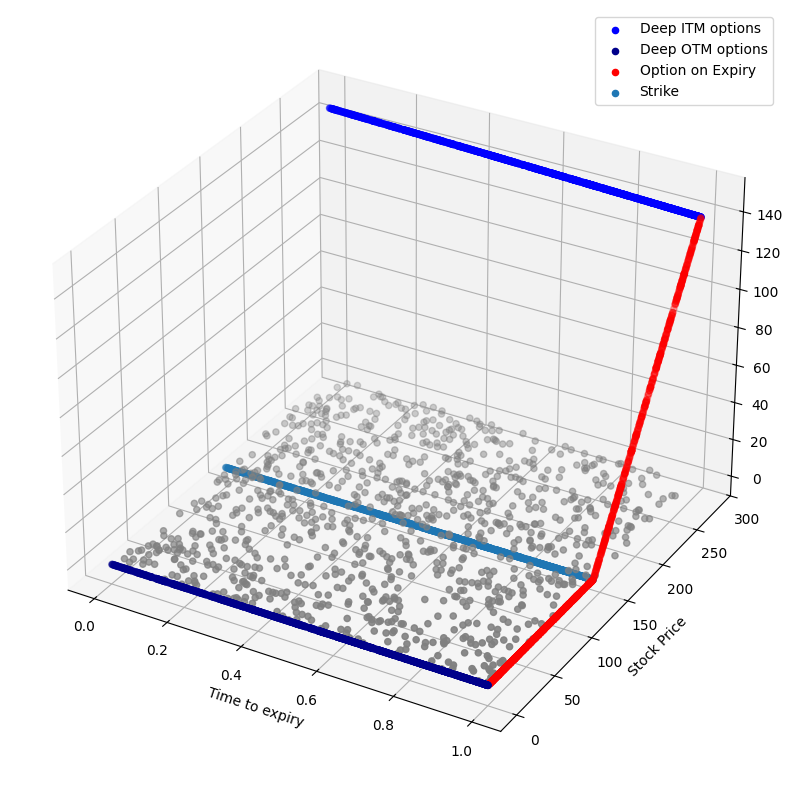

In [8]:
# Training-point visualization

X_tn,y_tn = EndPoints(1000,K)

X_bottom,y_bottom,X_top,y_top = BoundaryPoints(1000, K,r,T)

X_pde,y_pde = PDEPoints(1000)

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection = "3d")

ax.scatter3D(X_pde[:,0], X_pde[:,1], y_pde.flatten(), color='gray')
ax.scatter3D(X_top[:,0], X_top[:,1], y_top.flatten(), color='blue', label='Deep ITM options')
ax.scatter3D(X_bottom[:,0], X_bottom[:,1], y_bottom.flatten(), color='darkblue', label='Deep OTM options')
ax.scatter3D(X_tn[:,0], X_tn[:,1], y_tn.flatten(), color='red', label='Option on Expiry')
ax.scatter3D(X_top[:,0], K, 0, label="Strike")

plt.ylabel("Stock Price")
plt.xlabel("Time to expiry")

plt.legend(loc="upper right")

Neural Network

In [9]:
# Activation

class shiftedELU(nn.Module):
    def __init__(self,alpha = 0.001,K=0):
        super(shiftedELU,self).__init__()
        self.alpha = alpha
        self.K = K
        self.ELU = nn.ELU(alpha)

    def forward(self, x):
        return self.ELU(x-self.K)

In [10]:
# Gated PINN

class Gated_PINN(nn.Module):
    def __init__(self):
        super(Gated_PINN, self).__init__()
        self.K = K

        self.models = nn.ModuleList([self.create_single_model() for _ in range(9)])

        self.model_right = nn.Sequential(
            nn.Linear(2, 5),
            nn.Sigmoid(),
            nn.Linear(5, 9),
            nn.Softmax(dim=1)
        )

    def create_single_model(self):

        left_branch = nn.Sequential(
            nn.Linear(1, 5),
            nn.Softplus()
        )

        right_branch = nn.Sequential(
            nn.Linear(1, 5),
            nn.Sigmoid()
        )

        return nn.ModuleDict({
            'left': left_branch,
            'right': right_branch,
            'output': nn.Sequential(
                nn.Linear(5, 1, bias=False)
            )
        })

    def forward(self, x):

        t = x[:, 0].unsqueeze(1)
        spot = x[:, 1].unsqueeze(1)

        x = torch.cat((t, spot-self.K), dim=1)

        x_left = x[:,0].view(-1, 1)
        x_right = x[:,1].view(-1, 1)

        left_outputs = []
        for model in self.models:
            left_out = model['left'](x_left)
            right_out = model['right'](x_right)
            merged_out = left_out * right_out
            final_out = model['output'](merged_out)
            left_outputs.append(final_out)

        left_concatenated = torch.cat(left_outputs, dim=1)

        right_out = self.model_right(x)

        dot_output = torch.sum(left_concatenated * right_out, dim=1, keepdim=True)

        return dot_output

In [11]:
# Stable PINN architecture

class StablePINN(nn.Module):
    def __init__(self, strike=K, T_max=T):
        super(StablePINN, self).__init__()
        self.K = strike
        self.T = T_max

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        t = x[:, 0:1]
        S = x[:, 1:2]

        t_norm = (t - (self.T / 2)) / (self.T / 2)
        S_norm = (S - self.K) / self.K
        x_norm = torch.cat([t_norm, S_norm], dim=1)

        time_value = self.net(x_norm) * (self.K * 0.1)

        IV = torch.relu(S - self.K)

        return time_value + IV

Loss Function to Minimize

In [12]:
# PDE loss

mseloss = nn.MSELoss()
def pde_loss(outputs, inputs, sigma, r):

    frist_order = tgrad.grad(inputs = inputs, outputs=outputs.to(device), grad_outputs=torch.ones(outputs.shape).to(device),create_graph=True,retain_graph=True)[0]
    dC_dt = frist_order[:,0].view(-1,1)
    dC_dS = frist_order[:,1].view(-1,1)
    second_order = tgrad.grad(inputs=inputs,outputs=dC_dS.to(device),grad_outputs=torch.ones(dC_dS.shape).to(device),create_graph=True)[0]
    dC2_dS2 = second_order[:,1].view(-1,1)

    S = inputs[:,1].view(-1,1)

    return mseloss(dC_dt + .5*dC2_dS2*pow(sigma*S,2) + r*S*dC_dS, r*outputs)

def boundary_loss(pred, labels):
    return mseloss(pred,labels)

def pinn_loss(pde_loss,boundary_loss):
    return pde_loss + boundary_loss

Training

In [13]:
# Model

pinn = StablePINN(strike=K, T_max=T).to(device)
optimizer = optim.Adam(pinn.parameters(), lr=0.001)

In [14]:
loss_history = []
MSE_losses = []

In [15]:
print('Strike:',K)
print('Sigma:',sigma)
print('R:',r)

Strike: 140
Sigma: 0.18899999999999997
R: 0.0492


Initial training using Adam optimizer

In [16]:
# Training

optimizer = optim.Adam(pinn.parameters(), lr=0.0009)
lr_loss_weight = .1

loss_weight = torch.nn.Parameter(torch.from_numpy(np.array([1,1,1,1])).float())

start =0

physics_lr = 1.0
expiry_lr = 1.0
epochs = 3000

loss_history = []
MSE_losses = []

for itr in range(epochs):
    pinn.train()

    X_tn, y_tn = EndPoints(1000, K)
    X_tn = torch.from_numpy(X_tn).float().to(device)
    y_tn = torch.from_numpy(y_tn).float().to(device)

    X_bottom, y_bottom, X_top, y_top = BoundaryPoints(1000, K, r, T)
    X_bottom = torch.from_numpy(X_bottom).float().to(device)
    y_bottom = torch.from_numpy(y_bottom).float().to(device)
    X_top = torch.from_numpy(X_top).float().to(device)
    y_top = torch.from_numpy(y_top).float().to(device)

    X_pde, _ = PDEPoints(2500)
    X_pde = torch.from_numpy(X_pde).float().requires_grad_().to(device)

    C_pde = pinn(X_pde)
    C_tn = pinn(X_tn)
    C_top = pinn(X_top)
    C_bottom = pinn(X_bottom)

    pde_l = physics_lr * pde_loss(C_pde, X_pde, sigma, r)
    tn_l = expiry_lr * boundary_loss(C_tn, y_tn)
    sN_l = boundary_loss(C_top, y_top)
    s0_l = boundary_loss(C_bottom, y_bottom)

    total_loss = tn_l + sN_l + s0_l + pde_l
    MSE_losses.append([tn_l.item(), sN_l.item(), s0_l.item(), pde_l.item()])

    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(pinn.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(total_loss.item())

    if (itr + 1) % 50 == 0 or itr == 0:
        print(f"Epoch {itr+1}/{epochs} | Total Loss: {total_loss.item():.4f} "
              f"[Expiry: {tn_l.item():.4f}] [S=Max: {sN_l.item():.4f}] "
              f"[S=0: {s0_l.item():.4f}] [PDE: {pde_l.item():.4f}]")

    if total_loss.item() < 0.05:
        print(f"Converged at epoch {itr+1}!")
        break

Epoch 1/3000 | Total Loss: 46.1209 [Expiry: 7.7352] [S=Max: 4.7463] [S=0: 10.3069] [PDE: 23.3325]
Epoch 50/3000 | Total Loss: 3.3134 [Expiry: 0.0362] [S=Max: 0.0427] [S=0: 0.0569] [PDE: 3.1776]
Epoch 100/3000 | Total Loss: 2.6763 [Expiry: 0.0398] [S=Max: 0.0232] [S=0: 0.0869] [PDE: 2.5264]
Epoch 150/3000 | Total Loss: 2.0541 [Expiry: 0.0423] [S=Max: 0.0053] [S=0: 0.0644] [PDE: 1.9421]
Epoch 200/3000 | Total Loss: 1.4955 [Expiry: 0.0356] [S=Max: 0.0197] [S=0: 0.0188] [PDE: 1.4213]
Epoch 250/3000 | Total Loss: 1.1700 [Expiry: 0.0119] [S=Max: 0.0111] [S=0: 0.0349] [PDE: 1.1121]
Epoch 300/3000 | Total Loss: 0.9248 [Expiry: 0.0163] [S=Max: 0.0178] [S=0: 0.0137] [PDE: 0.8770]
Epoch 350/3000 | Total Loss: 0.4913 [Expiry: 0.0298] [S=Max: 0.0008] [S=0: 0.0051] [PDE: 0.4556]
Epoch 400/3000 | Total Loss: 0.3875 [Expiry: 0.0575] [S=Max: 0.0032] [S=0: 0.0116] [PDE: 0.3152]
Epoch 450/3000 | Total Loss: 0.3244 [Expiry: 0.0362] [S=Max: 0.0006] [S=0: 0.0048] [PDE: 0.2828]
Epoch 500/3000 | Total Loss: 0

Plotting Loss

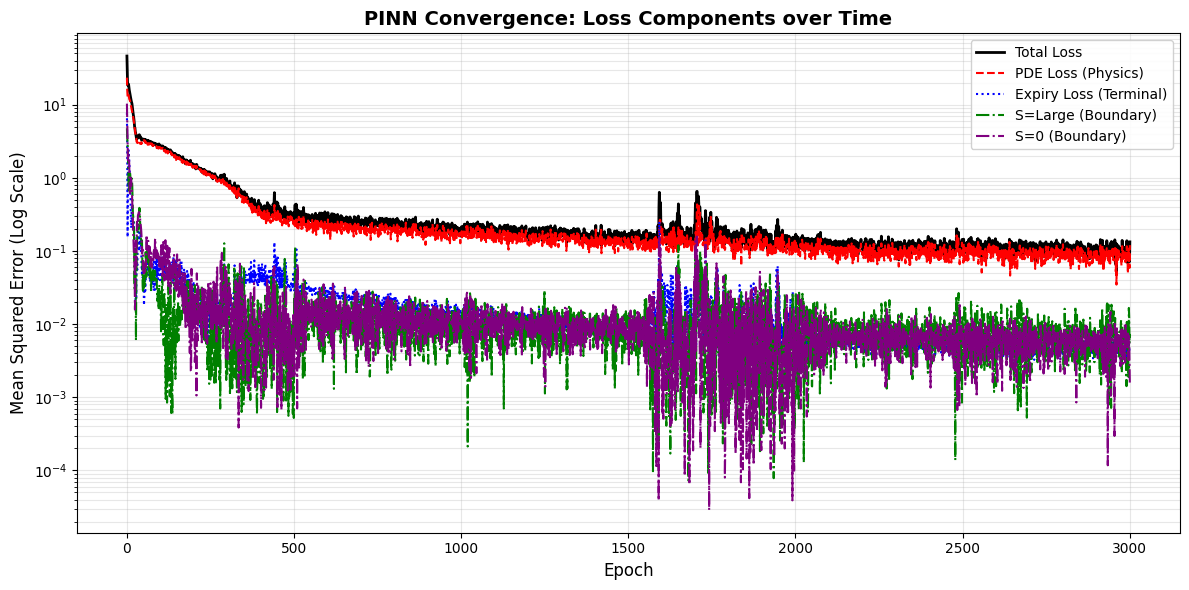

In [17]:
# Training loss

expiry_losses = [float(loss[0]) for loss in MSE_losses]
s_large_losses = [float(loss[1]) for loss in MSE_losses]
s_zero_losses = [float(loss[2]) for loss in MSE_losses]
pde_losses = [float(loss[3]) for loss in MSE_losses]

total_loss_arr = [float(loss) for loss in loss_history]

epochs_arr = np.arange(1, len(total_loss_arr) + 1)

plt.figure(figsize=(12, 6))

plt.plot(epochs_arr, total_loss_arr, label="Total Loss", color='black', linewidth=2)

plt.plot(epochs_arr, pde_losses, label="PDE Loss (Physics)", color='red', linestyle='--')
plt.plot(epochs_arr, expiry_losses, label="Expiry Loss (Terminal)", color='blue', linestyle=':')
plt.plot(epochs_arr, s_large_losses, label="S=Large (Boundary)", color='green', linestyle='-.')
plt.plot(epochs_arr, s_zero_losses, label="S=0 (Boundary)", color='purple', linestyle='-.')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (Log Scale)', fontsize=12)
plt.title('PINN Convergence: Loss Components over Time', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", framealpha=0.9)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()

plt.show()

Analysis of pricing across time frame

In [18]:
# Pricing across time

def time_frame_analysis(time_frame):
    spots = np.linspace(K-140,K+140,100)

    t = np.array([time_frame]*spots.shape[0])

    X_test = torch.tensor(np.concatenate((t.reshape(-1,1),spots.reshape(-1,1)),axis=1)).float().to(device)
    with torch.no_grad():
        pinn.eval()
        y_pinn = pinn(X_test)

    y_bsm = BSM_pricing(X_test[:,1],T-X_test[:,0],torch.tensor(K),torch.tensor(r),torch.tensor(sigma))
    plt.plot(spots,y_bsm.detach().cpu().numpy(),label = "BSM-pricing")
    plt.scatter(spots,y_pinn.detach().cpu().numpy(), s = 2, label = "PINN-pricing",color = "Red", marker='x')
    plt.title(f"Analysis of solution at t={time_frame}")

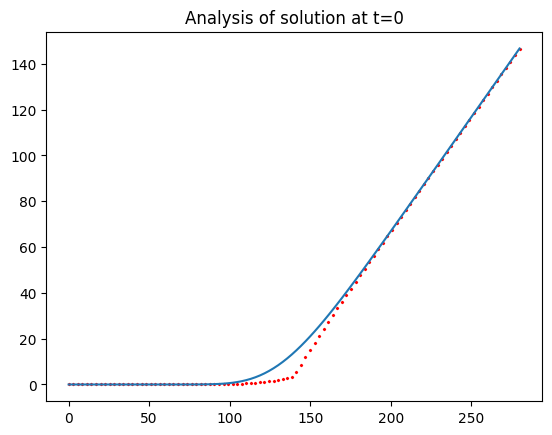

In [19]:
time_frame_analysis(0)

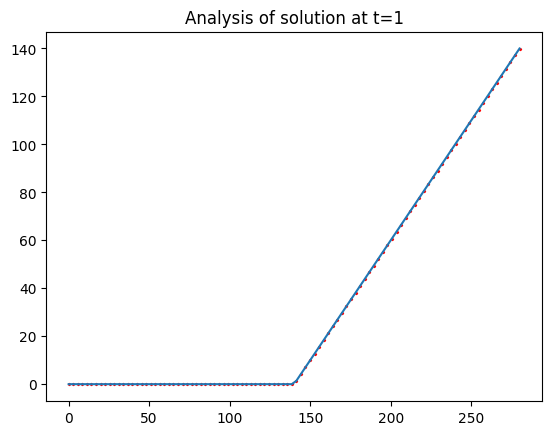

In [20]:
time_frame_analysis(1)

Analysis of PINNs vs BSM surface

In [21]:
s = np.linspace(0,S_range[1],1000)
t = np.linspace(0,T_range[1],1000)
s_grid, t_grid = np.meshgrid(s,t)

X_test = torch.Tensor(np.concatenate((t_grid.flatten().reshape(-1,1),s_grid.flatten().reshape(-1,1)),axis = 1)).float().to(device)
y_bsm_surface = BSM_pricing(X_test[:,1],X_test[:,0],torch.tensor(K),torch.tensor(r), torch.tensor(sigma))
with torch.no_grad():
    pinn.eval()
    y_pinn_surface = pinn(X_test)

MSE:  11.385303497314453


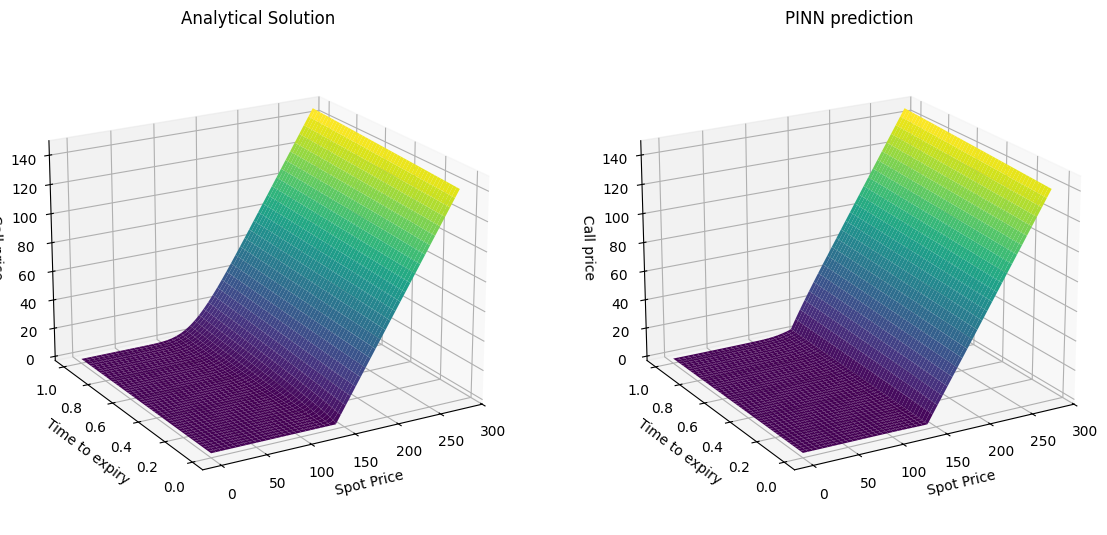

In [22]:
# Surface comparison

print("MSE: ", mseloss(y_bsm_surface.view(-1), y_pinn_surface.view(-1)).item())

fig = plt.figure(figsize=(14,7))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(s_grid, t_grid, y_bsm_surface.detach().cpu().numpy().reshape(s_grid.shape), cmap = "viridis")
ax.set_title("Analytical Solution")
ax.set_xlabel("Spot Price")
ax.set_ylabel("Time to expiry")
ax.set_zlabel("Call price")
ax.view_init(elev=20, azim=-120)

t_grid_pinn = 1 - t_grid
ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(s_grid, t_grid_pinn, y_pinn_surface.detach().cpu().numpy().reshape(s_grid.shape), cmap = "viridis")
ax.set_title("PINN prediction")
ax.set_xlabel("Spot Price")
ax.set_ylabel("Time to expiry")
ax.set_zlabel("Call price")
ax.view_init(elev=20, azim=-120)

In [23]:
# Market data

import yfinance as yf
import pandas as pd
import torch
import torch.nn as nn
import torch.autograd as tgrad
import torch.optim as optim

def get_live_option_data(ticker_symbol="AAPL"):
    ticker = yf.Ticker(ticker_symbol)
    S_live = ticker.history(period="1d")['Close'].iloc[-1]

    expiries = ticker.options
    if not expiries:
        raise ValueError(f"No options available for {ticker_symbol}")
    nearest_expiry = expiries[0]

    calls = ticker.option_chain(nearest_expiry).calls
    calls = calls[calls['volume'] > 0]

    expiry_date = pd.to_datetime(nearest_expiry)
    today = pd.to_datetime('today')
    t_to_expiry = max((expiry_date - today).days / 365.25, 0.005)

    t_tensor = torch.tensor([t_to_expiry] * len(calls), dtype=torch.float32).view(-1, 1)
    S_tensor = torch.tensor([S_live] * len(calls), dtype=torch.float32).view(-1, 1)
    K_tensor = torch.tensor(calls['strike'].values, dtype=torch.float32).view(-1, 1)

    X_market = torch.cat([t_tensor, S_tensor, K_tensor], dim=1).to(device)
    X_market.requires_grad_(True)

    market_prices = ((calls['bid'] + calls['ask']) / 2).values
    y_market = torch.tensor(market_prices, dtype=torch.float32).view(-1, 1).to(device)

    return X_market, y_market, S_live

X_market, y_market, S_live = get_live_option_data("AAPL")
print(f"Loaded {len(y_market)} live contracts. Current Spot: ${S_live:.2f}")

Loaded 78 live contracts. Current Spot: $335.92


In [24]:
# Market model

class LocalVolPINN(nn.Module):
    def __init__(self):
        super(LocalVolPINN, self).__init__()

        self.price_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.vol_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softplus()
        )

    def forward(self, x):
        t = x[:, 0:1]
        S = x[:, 1:2]
        K = x[:, 2:3]

        t_norm = t / 2.0
        S_norm = S / 1000.0
        K_norm = K / 1000.0
        x_norm = torch.cat([t_norm, S_norm, K_norm], dim=1)

        time_value = self.price_net(x_norm) * K * 0.1

        IV = torch.relu(S - K)

        C_pred = time_value + IV

        sigma_pred = self.vol_net(x_norm) + 1e-4

        return C_pred, sigma_pred

In [25]:
# Market calibration loss

def live_market_loss(pinn_model, X_market, y_market, r_rate=0.05):
    C_pred, sigma_pred = pinn_model(X_market)

    data_loss = nn.MSELoss()(C_pred, y_market)

    first_order = tgrad.grad(C_pred, X_market, grad_outputs=torch.ones_like(C_pred), create_graph=True)[0]
    dC_dt = first_order[:, 0:1]
    dC_dS = first_order[:, 1:2]

    second_order = tgrad.grad(dC_dS, X_market, grad_outputs=torch.ones_like(dC_dS), create_graph=True)[0]
    d2C_dS2 = second_order[:, 1:2]

    S = X_market[:, 1:2]

    pde_residual = dC_dt + 0.5 * (sigma_pred * S)**2 * d2C_dS2 + r_rate * S * dC_dS - r_rate * C_pred
    pde_loss = nn.MSELoss()(pde_residual, torch.zeros_like(pde_residual))

    monotonicity_penalty = torch.mean(torch.relu(-dC_dS)**2)

    convexity_penalty = torch.mean(torch.relu(-d2C_dS2)**2)

    arbitrage_loss = monotonicity_penalty + convexity_penalty

    return data_loss, pde_loss, arbitrage_loss

In [26]:
# Market model training

live_pinn = LocalVolPINN().to(device)
optimizer = optim.Adam(live_pinn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)

lambda_data = 1.0
lambda_pde = 0.1
lambda_arb = 10.0

epochs = 3000
risk_free_rate = 0.05

for epoch in range(epochs):
    live_pinn.train()
    optimizer.zero_grad()

    data_l, pde_l, arb_l = live_market_loss(live_pinn, X_market, y_market, risk_free_rate)

    total_loss = (lambda_data * data_l) + (lambda_pde * pde_l) + (lambda_arb * arb_l)

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(live_pinn.parameters(), max_norm=1.0)
    optimizer.step()

    scheduler.step(total_loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Total: {total_loss.item():.4f} "
              f"[Data: {data_l.item():.4f}] [PDE: {pde_l.item():.4f}] [Arb: {arb_l.item():.4f}]")

print("Live Market Calibration Complete.")

Epoch 100/3000 | Total: 2282.5278 [Data: 2267.4883] [PDE: 150.3948] [Arb: 0.0000]
Epoch 200/3000 | Total: 136.6086 [Data: 133.4091] [PDE: 31.9950] [Arb: 0.0000]
Epoch 300/3000 | Total: 71.3408 [Data: 68.9025] [PDE: 24.3832] [Arb: 0.0000]
Epoch 400/3000 | Total: 38.7052 [Data: 36.9214] [PDE: 17.8377] [Arb: 0.0000]
Epoch 500/3000 | Total: 20.2519 [Data: 18.6614] [PDE: 15.9043] [Arb: 0.0000]
Epoch 600/3000 | Total: 17.5159 [Data: 16.0879] [PDE: 14.2799] [Arb: 0.0000]
Epoch 700/3000 | Total: 17.9953 [Data: 16.6664] [PDE: 13.2889] [Arb: 0.0000]
Epoch 800/3000 | Total: 10.8144 [Data: 9.6332] [PDE: 11.8120] [Arb: 0.0000]
Epoch 900/3000 | Total: 12.2301 [Data: 9.8067] [PDE: 24.2349] [Arb: 0.0000]
Epoch 1000/3000 | Total: 8.5807 [Data: 7.5538] [PDE: 10.2693] [Arb: 0.0000]
Epoch 1100/3000 | Total: 10.7797 [Data: 9.5964] [PDE: 11.8333] [Arb: 0.0000]
Epoch 1200/3000 | Total: 17.0409 [Data: 16.0509] [PDE: 9.9001] [Arb: 0.0000]
Epoch 1300/3000 | Total: 9.5358 [Data: 8.6717] [PDE: 8.6402] [Arb: 0.000

In [27]:
import random
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 52

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", device)
print("Random seed:", SEED)

Device: cuda:0
Random seed: 52


In [28]:
def bsm_from_elapsed_time(S, elapsed_t, K, T, r, sigma):
    """
    Black-Scholes analytical price using the same time convention
    as the PINN: elapsed time t, where tau = T - t.
    """
    tau = torch.clamp(
        torch.as_tensor(T, dtype=S.dtype, device=S.device) - elapsed_t,
        min=1e-8
    )

    return BSM_pricing(
        S,
        tau,
        torch.as_tensor(K, dtype=S.dtype, device=S.device),
        torch.as_tensor(r, dtype=S.dtype, device=S.device),
        torch.as_tensor(sigma, dtype=S.dtype, device=S.device)
    )

In [29]:
# Independent evaluation grid

N_S = 250
N_T = 100

S_test_np = np.linspace(
    max(1e-4, S_range[0]),
    S_range[1],
    N_S
)

t_test_np = np.linspace(
    T_range[0],
    T_range[1] - 1e-5,
    N_T
)

S_grid_eval, t_grid_eval = np.meshgrid(S_test_np, t_test_np)

X_eval = torch.tensor(
    np.column_stack([
        t_grid_eval.ravel(),
        S_grid_eval.ravel()
    ]),
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    pinn.eval()
    y_pinn_eval = pinn(X_eval).view(-1)

y_bsm_eval = bsm_from_elapsed_time(
    X_eval[:, 1],
    X_eval[:, 0],
    K,
    T,
    r,
    sigma
).view(-1)

print("Evaluation points:", len(X_eval))
print("PINN predictions:", y_pinn_eval.shape)
print("BSM reference:", y_bsm_eval.shape)

Evaluation points: 25000
PINN predictions: torch.Size([25000])
BSM reference: torch.Size([25000])


In [30]:
def regression_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_pred - y_true
    abs_error = np.abs(error)

    return {
        "MSE": np.mean(error ** 2),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAE": np.mean(abs_error),
        "Max Absolute Error": np.max(abs_error),
        "Mean Relative Error (%)":
            np.mean(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "Median Relative Error (%)":
            np.median(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "R2":
            1 - np.sum(error ** 2) /
            np.maximum(np.sum((y_true - np.mean(y_true)) ** 2), eps)
    }

metrics_pinn = regression_metrics(
    y_bsm_eval.detach().cpu().numpy(),
    y_pinn_eval.detach().cpu().numpy()
)

metrics_df = pd.DataFrame(
    metrics_pinn.items(),
    columns=["Metric", "PINN"]
)

display(metrics_df)

,Metric,PINN
0,MSE,2.761555e+00
1,RMSE,1.661793e+00
2,MAE,6.419876e-01
3,Max Absolute Error,1.005858e+01
4,Mean Relative Error (%),2.285998e+08
5,Median Relative Error (%),4.305871e+01
6,R2,9.987140e-01


In [31]:
def regression_metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_pred - y_true
    abs_error = np.abs(error)

    return {
        "MSE": np.mean(error ** 2),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAE": np.mean(abs_error),
        "Max Absolute Error": np.max(abs_error),
        "Mean Relative Error (%)":
            np.mean(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "Median Relative Error (%)":
            np.median(abs_error / np.maximum(np.abs(y_true), eps)) * 100,
        "R2":
            1 - np.sum(error ** 2) /
            np.maximum(np.sum((y_true - np.mean(y_true)) ** 2), eps)
    }

metrics_pinn = regression_metrics(
    y_bsm_eval.detach().cpu().numpy(),
    y_pinn_eval.detach().cpu().numpy()
)

metrics_df = pd.DataFrame(
    metrics_pinn.items(),
    columns=["Metric", "PINN"]
)

display(metrics_df)

,Metric,PINN
0,MSE,2.761555e+00
1,RMSE,1.661793e+00
2,MAE,6.419876e-01
3,Max Absolute Error,1.005858e+01
4,Mean Relative Error (%),2.285998e+08
5,Median Relative Error (%),4.305871e+01
6,R2,9.987140e-01


In [32]:
# Data-driven baseline

class DataDrivenNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        t = x[:, 0:1]
        S = x[:, 1:2]

        t_norm = (t - T / 2) / (T / 2)
        S_norm = (S - K) / K

        return self.net(torch.cat([t_norm, S_norm], dim=1)) * (K * 0.1)

In [33]:
# Baseline dataset

N_SUPERVISED = 2000

rng = np.random.default_rng(SEED)

t_train = rng.uniform(
    T_range[0],
    T_range[1] - 1e-5,
    N_SUPERVISED
)

S_train = rng.uniform(
    S_range[0],
    S_range[1],
    N_SUPERVISED
)

X_train_nn = torch.tensor(
    np.column_stack([t_train, S_train]),
    dtype=torch.float32,
    device=device
)

y_train_nn = bsm_from_elapsed_time(
    X_train_nn[:, 1],
    X_train_nn[:, 0],
    K,
    T,
    r,
    sigma
).view(-1, 1).detach()

print("Supervised training samples:", N_SUPERVISED)

Supervised training samples: 2000


In [34]:
baseline_nn = DataDrivenNN().to(device)

baseline_optimizer = optim.Adam(
    baseline_nn.parameters(),
    lr=1e-3
)

baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer,
    mode="min",
    factor=0.5,
    patience=200
)

baseline_history = []

EPOCHS_BASELINE = 3000

start_time = time.time()

for epoch in range(EPOCHS_BASELINE):

    baseline_nn.train()
    baseline_optimizer.zero_grad()

    prediction = baseline_nn(X_train_nn)

    loss = nn.MSELoss()(prediction, y_train_nn)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        baseline_nn.parameters(),
        max_norm=1.0
    )

    baseline_optimizer.step()
    baseline_scheduler.step(loss.item())

    baseline_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1}/{EPOCHS_BASELINE} | "
            f"Loss: {loss.item():.6f}"
        )

baseline_training_time = time.time() - start_time

print(f"\nBaseline training time: {baseline_training_time:.2f} seconds")

Epoch 500/3000 | Loss: 0.266380
Epoch 1000/3000 | Loss: 0.392646
Epoch 1500/3000 | Loss: 0.285689
Epoch 2000/3000 | Loss: 0.110432
Epoch 2500/3000 | Loss: 0.028255
Epoch 3000/3000 | Loss: 0.023767

Baseline training time: 4.57 seconds


In [35]:
with torch.no_grad():
    baseline_nn.eval()
    y_baseline_eval = baseline_nn(X_eval).view(-1)

baseline_metrics = regression_metrics(
    y_bsm_eval.detach().cpu().numpy(),
    y_baseline_eval.detach().cpu().numpy()
)

comparison_df = pd.DataFrame({
    "Metric": list(metrics_pinn.keys()),
    "PINN": list(metrics_pinn.values()),
    "Data-Driven NN": list(baseline_metrics.values())
})

display(comparison_df)

,Metric,PINN,Data-Driven NN
0,MSE,2.761555e+00,2.080281e-02
1,RMSE,1.661793e+00,1.442318e-01
2,MAE,6.419876e-01,8.297395e-02
3,Max Absolute Error,1.005858e+01,3.070999e+00
4,Mean Relative Error (%),2.285998e+08,2.063311e+08
5,Median Relative Error (%),4.305871e+01,1.222076e+00
6,R2,9.987140e-01,9.999903e-01


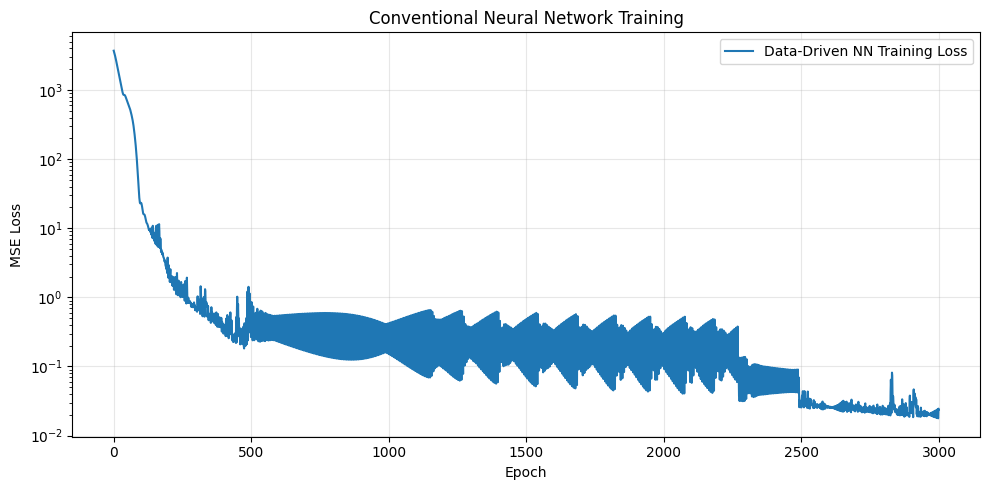

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_history,
    label="Data-Driven NN Training Loss"
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conventional Neural Network Training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

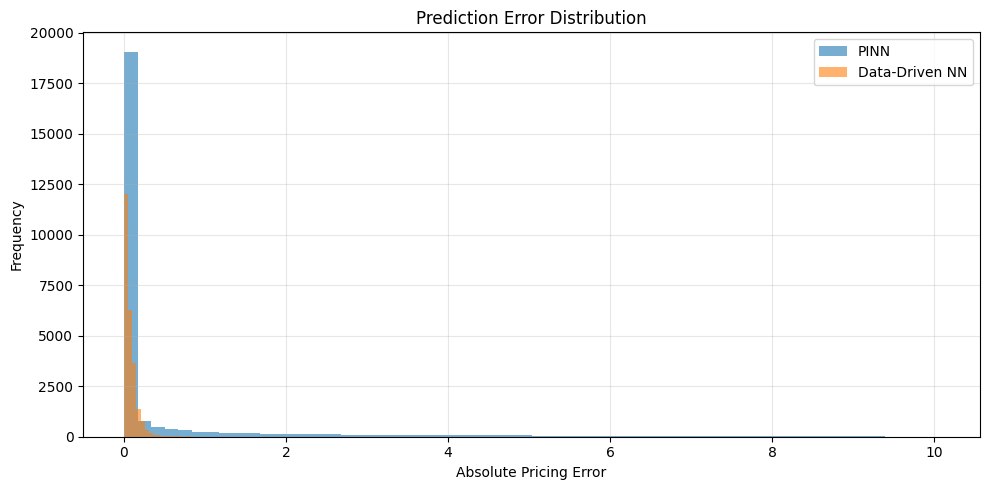

In [37]:
true_np = y_bsm_eval.detach().cpu().numpy()
pinn_np = y_pinn_eval.detach().cpu().numpy()
baseline_np = y_baseline_eval.detach().cpu().numpy()

pinn_abs_error = np.abs(pinn_np - true_np)
baseline_abs_error = np.abs(baseline_np - true_np)

plt.figure(figsize=(10, 5))

plt.hist(
    pinn_abs_error,
    bins=60,
    alpha=0.6,
    label="PINN"
)

plt.hist(
    baseline_abs_error,
    bins=60,
    alpha=0.6,
    label="Data-Driven NN"
)

plt.xlabel("Absolute Pricing Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
eval_df = pd.DataFrame({
    "t": X_eval[:, 0].detach().cpu().numpy(),
    "S": X_eval[:, 1].detach().cpu().numpy(),
    "BSM": true_np,
    "PINN": pinn_np,
    "Baseline": baseline_np
})

eval_df["Moneyness"] = eval_df["S"] / K
eval_df["PINN_Abs_Error"] = np.abs(
    eval_df["PINN"] - eval_df["BSM"]
)

eval_df["Baseline_Abs_Error"] = np.abs(
    eval_df["Baseline"] - eval_df["BSM"]
)

moneyness_bins = [
    0.0, 0.8, 0.9, 0.95, 1.0,
    1.05, 1.10, 1.20, 10.0
]

moneyness_labels = [
    "<0.80",
    "0.80–0.90",
    "0.90–0.95",
    "0.95–1.00",
    "1.00–1.05",
    "1.05–1.10",
    "1.10–1.20",
    ">1.20"
]

eval_df["Moneyness_Bin"] = pd.cut(
    eval_df["Moneyness"],
    bins=moneyness_bins,
    labels=moneyness_labels,
    include_lowest=True
)

moneyness_results = (
    eval_df
    .groupby("Moneyness_Bin", observed=True)
    .agg(
        PINN_MAE=("PINN_Abs_Error", "mean"),
        Baseline_MAE=("Baseline_Abs_Error", "mean"),
        Samples=("PINN_Abs_Error", "size")
    )
    .reset_index()
)

display(moneyness_results)

,Moneyness_Bin,PINN_MAE,Baseline_MAE,Samples
0,<0.80,0.115979,0.077962,10000
1,0.80–0.90,1.349546,0.138837,1300
2,0.90–0.95,3.348961,0.200955,600
3,0.95–1.00,5.550958,0.294864,600
4,1.00–1.05,5.367073,0.209082,600
5,1.05–1.10,3.125359,0.052934,600
6,1.10–1.20,1.353891,0.122658,1300
7,>1.20,0.094002,0.050009,10000


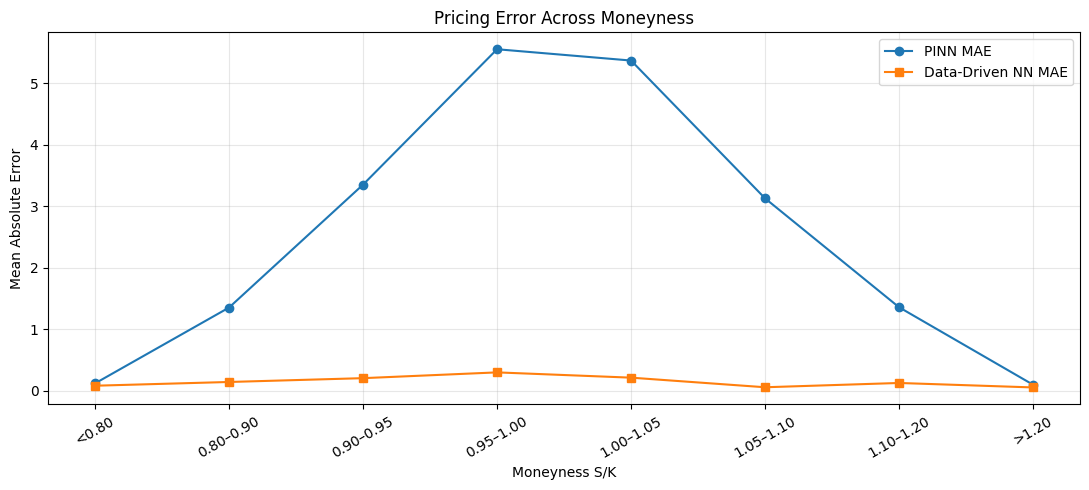

In [39]:
plt.figure(figsize=(11, 5))

x = np.arange(len(moneyness_results))

plt.plot(
    x,
    moneyness_results["PINN_MAE"],
    marker="o",
    label="PINN MAE"
)

plt.plot(
    x,
    moneyness_results["Baseline_MAE"],
    marker="s",
    label="Data-Driven NN MAE"
)

plt.xticks(
    x,
    moneyness_results["Moneyness_Bin"],
    rotation=30
)

plt.xlabel("Moneyness S/K")
plt.ylabel("Mean Absolute Error")
plt.title("Pricing Error Across Moneyness")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
eval_df["PINN_Rel_Error_%"] = (
    eval_df["PINN_Abs_Error"] /
    np.maximum(np.abs(eval_df["BSM"]), 1e-6)
) * 100

eval_df["Baseline_Rel_Error_%"] = (
    eval_df["Baseline_Abs_Error"] /
    np.maximum(np.abs(eval_df["BSM"]), 1e-6)
) * 100

time_bins = np.linspace(
    T_range[0],
    T_range[1],
    11
)

eval_df["Time_Bin"] = pd.cut(
    eval_df["t"],
    bins=time_bins,
    include_lowest=True
)

time_results = (
    eval_df
    .groupby("Time_Bin", observed=True)
    .agg(
        PINN_MAE=("PINN_Abs_Error", "mean"),
        Baseline_MAE=("Baseline_Abs_Error", "mean"),
        PINN_Rel_Error=("PINN_Rel_Error_%", "mean"),
        Baseline_Rel_Error=("Baseline_Rel_Error_%", "mean"),
        Samples=("PINN_Abs_Error", "size")
    )
    .reset_index()
)

display(time_results)

,Time_Bin,PINN_MAE,Baseline_MAE,PINN_Rel_Error,Baseline_Rel_Error,Samples
0,"(-0.001, 0.1]",1.159173,0.102560,1977606.00,2699254.500,2500
1,"(0.1, 0.2]",1.046035,0.059333,2048008.75,1140282.625,2500
2,"(0.2, 0.3]",0.931803,0.044377,2104483.25,778797.500,2500
3,"(0.3, 0.4]",0.817301,0.057909,2163627.50,1366885.625,2500
4,"(0.4, 0.5]",0.701759,0.075027,2210292.00,2025755.000,2500
5,"(0.5, 0.6]",0.585556,0.084290,2370509.00,2469197.000,2500
6,"(0.6, 0.7]",0.469357,0.079048,2594772.00,2393841.750,2500
7,"(0.7, 0.8]",0.353291,0.058909,2927032.50,1711191.125,2500
8,"(0.8, 0.9]",0.236769,0.074048,3250181.00,1353851.375,2500
9,"(0.9, 1.0]",0.118833,0.194238,3408350.25,7076399.500,2500


In [41]:
# Constraint diagnostics

def evaluate_constraints(model, n=500):
    model.eval()

    t_vals = torch.linspace(
        0,
        T - 1e-5,
        n,
        device=device
    ).view(-1, 1)

    X_zero = torch.cat(
        [t_vals, torch.zeros_like(t_vals)],
        dim=1
    )

    S_max = torch.full_like(t_vals, float(S_range[1]))

    X_large = torch.cat(
        [t_vals, S_max],
        dim=1
    )

    S_terminal = torch.linspace(
        S_range[0],
        S_range[1],
        n,
        device=device
    ).view(-1, 1)

    t_terminal = torch.full_like(
        S_terminal,
        float(T)
    )

    X_terminal = torch.cat(
        [t_terminal, S_terminal],
        dim=1
    )

    with torch.no_grad():
        pred_zero = model(X_zero)
        pred_large = model(X_large)
        pred_terminal = model(X_terminal)

    target_zero = torch.zeros_like(pred_zero)

    target_large = (
        S_max -
        K * torch.exp(-r * (T - t_vals))
    )

    target_terminal = torch.relu(
        S_terminal - K
    )

    return {
        "S=0 MAE":
            torch.mean(
                torch.abs(pred_zero - target_zero)
            ).item(),

        "S=max MAE":
            torch.mean(
                torch.abs(pred_large - target_large)
            ).item(),

        "Terminal MAE":
            torch.mean(
                torch.abs(pred_terminal - target_terminal)
            ).item()
    }

constraint_results = evaluate_constraints(pinn)

display(
    pd.DataFrame(
        constraint_results.items(),
        columns=["Constraint", "MAE"]
    )
)

,Constraint,MAE
0,S=0 MAE,0.111208
1,S=max MAE,0.053616
2,Terminal MAE,0.066086


In [42]:
# PDE diagnostics

def calculate_pde_residual(model, X, sigma_value=sigma, r_value=r):
    X = X.clone().detach().requires_grad_(True)

    output = model(X)

    first_order = torch.autograd.grad(
        output,
        X,
        grad_outputs=torch.ones_like(output),
        create_graph=True
    )[0]

    dC_dt = first_order[:, 0:1]
    dC_dS = first_order[:, 1:2]

    second_order = torch.autograd.grad(
        dC_dS,
        X,
        grad_outputs=torch.ones_like(dC_dS),
        create_graph=True
    )[0]

    d2C_dS2 = second_order[:, 1:2]

    S = X[:, 1:2]

    residual = (
        dC_dt
        + 0.5 * (sigma_value * S) ** 2 * d2C_dS2
        + r_value * S * dC_dS
        - r_value * output
    )

    return residual.detach()

N_PDE_TEST = 5000

X_pde_test = torch.tensor(
    np.column_stack([
        np.random.uniform(0, T - 1e-5, N_PDE_TEST),
        np.random.uniform(S_range[0], S_range[1], N_PDE_TEST)
    ]),
    dtype=torch.float32,
    device=device
)

pde_residual = calculate_pde_residual(
    pinn,
    X_pde_test
)

pde_metrics = {
    "Mean |PDE residual|":
        torch.mean(torch.abs(pde_residual)).item(),

    "RMS PDE residual":
        torch.sqrt(torch.mean(pde_residual ** 2)).item(),

    "Maximum |PDE residual|":
        torch.max(torch.abs(pde_residual)).item()
}

display(
    pd.DataFrame(
        pde_metrics.items(),
        columns=["Metric", "Value"]
    )
)

,Metric,Value
0,Mean |PDE residual|,0.131572
1,RMS PDE residual,0.286301
2,Maximum |PDE residual|,3.597572


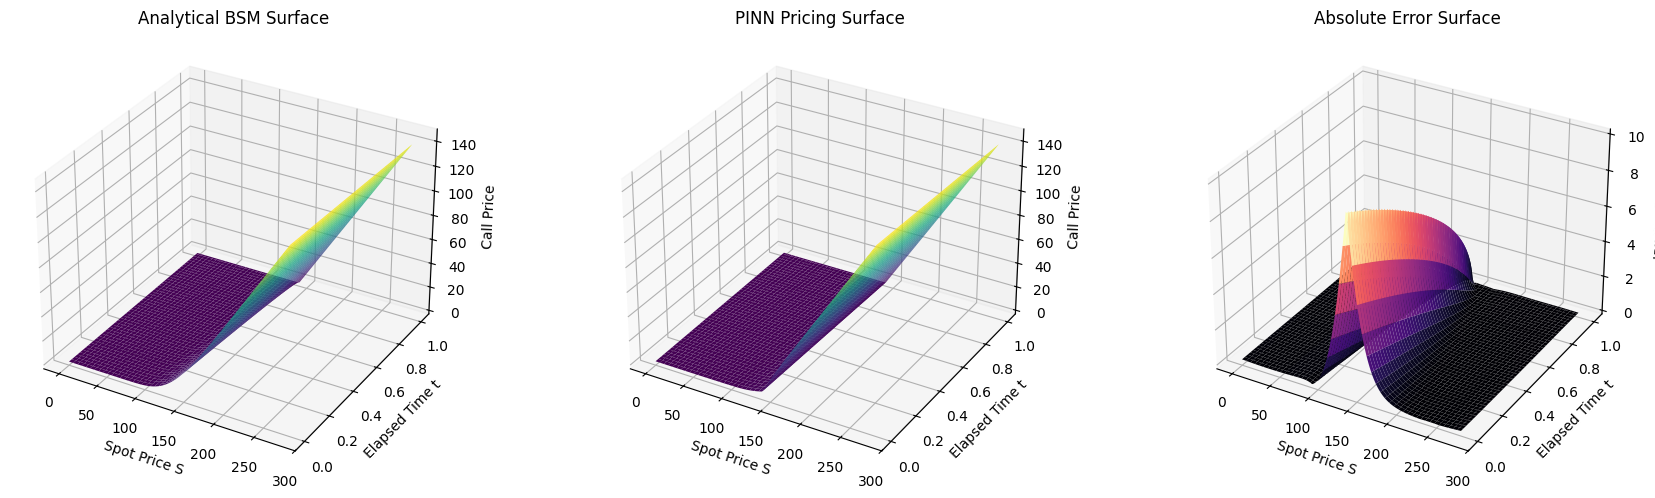

In [43]:
# Surface visualization

bsm_surface = true_np.reshape(t_grid_eval.shape)
pinn_surface = pinn_np.reshape(t_grid_eval.shape)

error_surface = np.abs(
    pinn_surface - bsm_surface
)

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(
    S_grid_eval,
    t_grid_eval,
    bsm_surface,
    cmap="viridis"
)
ax1.set_title("Analytical BSM Surface")
ax1.set_xlabel("Spot Price S")
ax1.set_ylabel("Elapsed Time t")
ax1.set_zlabel("Call Price")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(
    S_grid_eval,
    t_grid_eval,
    pinn_surface,
    cmap="viridis"
)
ax2.set_title("PINN Pricing Surface")
ax2.set_xlabel("Spot Price S")
ax2.set_ylabel("Elapsed Time t")
ax2.set_zlabel("Call Price")

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(
    S_grid_eval,
    t_grid_eval,
    error_surface,
    cmap="magma"
)
ax3.set_title("Absolute Error Surface")
ax3.set_xlabel("Spot Price S")
ax3.set_ylabel("Elapsed Time t")
ax3.set_zlabel("|PINN - BSM|")

plt.tight_layout()
plt.show()

In [44]:
N_OOS = 10000

rng_oos = np.random.default_rng(2026)

X_oos = torch.tensor(
    np.column_stack([
        rng_oos.uniform(
            T_range[0],
            T_range[1] - 1e-5,
            N_OOS
        ),
        rng_oos.uniform(
            S_range[0],
            S_range[1],
            N_OOS
        )
    ]),
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    pinn.eval()
    y_oos_pinn = pinn(X_oos).view(-1)

y_oos_bsm = bsm_from_elapsed_time(
    X_oos[:, 1],
    X_oos[:, 0],
    K,
    T,
    r,
    sigma
).view(-1)

oos_metrics = regression_metrics(
    y_oos_bsm.detach().cpu().numpy(),
    y_oos_pinn.detach().cpu().numpy()
)

display(
    pd.DataFrame(
        oos_metrics.items(),
        columns=["Metric", "OOS PINN"]
    )
)

,Metric,OOS PINN
0,MSE,2.810106e+00
1,RMSE,1.676337e+00
2,MAE,6.442076e-01
3,Max Absolute Error,9.791603e+00
4,Mean Relative Error (%),2.275519e+08
5,Median Relative Error (%),5.027611e+01
6,R2,9.986623e-01


In [45]:
summary = pd.DataFrame({
    "Metric": list(metrics_pinn.keys()),
    "PINN": list(metrics_pinn.values()),
    "Data-Driven NN": list(baseline_metrics.values())
})

summary

,Metric,PINN,Data-Driven NN
0,MSE,2.761555e+00,2.080281e-02
1,RMSE,1.661793e+00,1.442318e-01
2,MAE,6.419876e-01,8.297395e-02
3,Max Absolute Error,1.005858e+01,3.070999e+00
4,Mean Relative Error (%),2.285998e+08,2.063311e+08
5,Median Relative Error (%),4.305871e+01,1.222076e+00
6,R2,9.987140e-01,9.999903e-01


In [46]:
live_pinn.eval()

with torch.no_grad():
    live_prices, live_sigmas = live_pinn(X_market)

live_true = y_market.detach().cpu().numpy().reshape(-1)
live_pred = live_prices.detach().cpu().numpy().reshape(-1)
live_vol = live_sigmas.detach().cpu().numpy().reshape(-1)

live_metrics = regression_metrics(
    live_true,
    live_pred
)

print("Live Market Calibration Metrics")

display(
    pd.DataFrame(
        live_metrics.items(),
        columns=["Metric", "Value"]
    )
)

print(
    f"\nContracts evaluated: {len(live_true)}"
)
print(
    f"Predicted volatility range: "
    f"{live_vol.min():.4f} – {live_vol.max():.4f}"
)

Live Market Calibration Metrics


,Metric,Value
0,MSE,1.380824e+00
1,RMSE,1.175085e+00
2,MAE,1.084267e+00
3,Max Absolute Error,3.000946e+00
4,Mean Relative Error (%),1.084267e+10
5,Median Relative Error (%),1.050781e+10
6,R2,-1.077043e+10



Contracts evaluated: 78
Predicted volatility range: 0.0069 – 0.0075


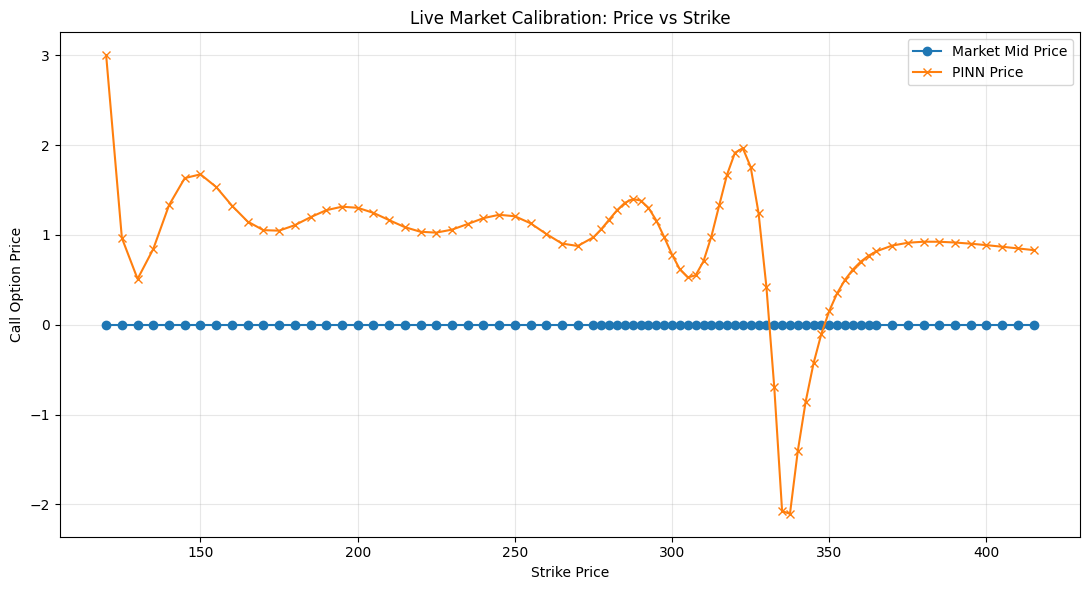

In [47]:
live_df = pd.DataFrame({
    "Strike": X_market[:, 2].detach().cpu().numpy(),
    "Market Price": live_true,
    "PINN Price": live_pred,
    "Predicted Volatility": live_vol
})

live_df["Absolute Error"] = np.abs(
    live_df["PINN Price"] -
    live_df["Market Price"]
)

live_df = live_df.sort_values("Strike")

plt.figure(figsize=(11, 6))

plt.plot(
    live_df["Strike"],
    live_df["Market Price"],
    marker="o",
    label="Market Mid Price"
)

plt.plot(
    live_df["Strike"],
    live_df["PINN Price"],
    marker="x",
    label="PINN Price"
)

plt.xlabel("Strike Price")
plt.ylabel("Call Option Price")
plt.title("Live Market Calibration: Price vs Strike")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

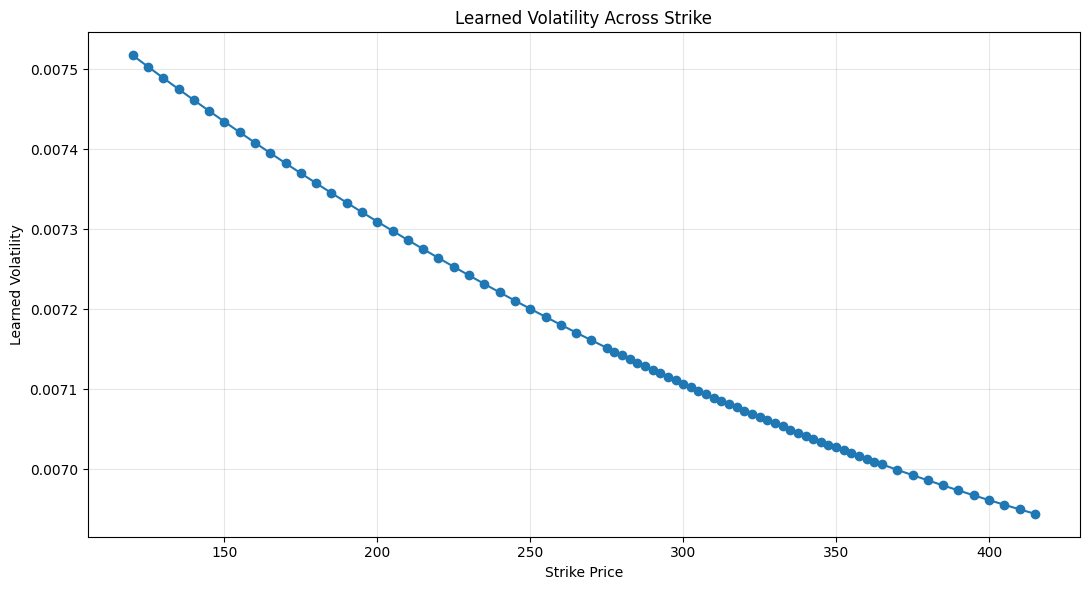

In [48]:
plt.figure(figsize=(11, 6))

plt.plot(
    live_df["Strike"],
    live_df["Predicted Volatility"],
    marker="o"
)

plt.xlabel("Strike Price")
plt.ylabel("Learned Volatility")
plt.title("Learned Volatility Across Strike")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
def calculate_greeks(model, X):
    X = X.clone().detach().requires_grad_(True)

    C, sigma_pred = model(X)

    first = torch.autograd.grad(
        C,
        X,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    delta = first[:, 1:2]

    second = torch.autograd.grad(
        delta,
        X,
        grad_outputs=torch.ones_like(delta),
        create_graph=True
    )[0]

    gamma = second[:, 1:2]

    return (
        C.detach(),
        sigma_pred.detach(),
        delta.detach(),
        gamma.detach()
    )

C_live, sigma_live, delta_live, gamma_live = calculate_greeks(
    live_pinn,
    X_market
)

greek_metrics = {
    "Minimum Delta": delta_live.min().item(),
    "Maximum Delta": delta_live.max().item(),
    "Negative Delta violations":
        torch.sum(delta_live < 0).item(),

    "Minimum Gamma": gamma_live.min().item(),
    "Maximum Gamma": gamma_live.max().item(),
    "Negative Gamma violations":
        torch.sum(gamma_live < 0).item()
}

display(
    pd.DataFrame(
        greek_metrics.items(),
        columns=["Diagnostic", "Value"]
    )
)

,Diagnostic,Value
0,Minimum Delta,-0.001005
1,Maximum Delta,1.209855
2,Negative Delta violations,10.000000
3,Minimum Gamma,-0.000265
4,Maximum Gamma,0.000382
5,Negative Gamma violations,66.000000


In [50]:
def live_pde_residual(model, X, r_rate=0.05):
    X = X.clone().detach().requires_grad_(True)

    C, sigma_pred = model(X)

    first = torch.autograd.grad(
        C,
        X,
        grad_outputs=torch.ones_like(C),
        create_graph=True
    )[0]

    dC_dt = first[:, 0:1]
    dC_dS = first[:, 1:2]

    second = torch.autograd.grad(
        dC_dS,
        X,
        grad_outputs=torch.ones_like(dC_dS),
        create_graph=True
    )[0]

    d2C_dS2 = second[:, 1:2]

    S = X[:, 1:2]

    residual = (
        dC_dt
        + 0.5 * (sigma_pred * S) ** 2 * d2C_dS2
        + r_rate * S * dC_dS
        - r_rate * C
    )

    return residual.detach()

live_residual = live_pde_residual(
    live_pinn,
    X_market,
    risk_free_rate
)

live_pde_metrics = {
    "Mean |PDE residual|":
        torch.mean(torch.abs(live_residual)).item(),

    "RMS PDE residual":
        torch.sqrt(torch.mean(live_residual ** 2)).item(),

    "Maximum |PDE residual|":
        torch.max(torch.abs(live_residual)).item()
}

display(
    pd.DataFrame(
        live_pde_metrics.items(),
        columns=["Metric", "Value"]
    )
)

,Metric,Value
0,Mean |PDE residual|,1.088954
1,RMS PDE residual,2.107852
2,Maximum |PDE residual|,10.208143


In [51]:
# Market train-test split

N_market = len(X_market)

rng = np.random.default_rng(SEED)
indices = rng.permutation(N_market)

split = int(0.8 * N_market)

train_idx = indices[:split]
test_idx = indices[split:]

X_market_train = X_market[train_idx].clone().detach().requires_grad_(True)
y_market_train = y_market[train_idx]

X_market_test = X_market[test_idx].clone().detach().requires_grad_(True)
y_market_test = y_market[test_idx]

print("Market contracts:", N_market)
print("Training contracts:", len(train_idx))
print("Test contracts:", len(test_idx))

Market contracts: 78
Training contracts: 62
Test contracts: 16


In [52]:
live_pinn_oos = LocalVolPINN().to(device)

optimizer_oos = optim.Adam(
    live_pinn_oos.parameters(),
    lr=1e-3
)

scheduler_oos = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_oos,
    mode="min",
    factor=0.5,
    patience=200
)

OOS_EPOCHS = 3000

oos_history = []

for epoch in range(OOS_EPOCHS):

    live_pinn_oos.train()
    optimizer_oos.zero_grad()

    data_l, pde_l, arb_l = live_market_loss(
        live_pinn_oos,
        X_market_train,
        y_market_train,
        risk_free_rate
    )

    total_l = (
        lambda_data * data_l
        + lambda_pde * pde_l
        + lambda_arb * arb_l
    )

    total_l.backward()

    torch.nn.utils.clip_grad_norm_(
        live_pinn_oos.parameters(),
        max_norm=1.0
    )

    optimizer_oos.step()
    scheduler_oos.step(total_l.item())

    oos_history.append(total_l.item())

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1}/{OOS_EPOCHS} | "
            f"Total: {total_l.item():.4f} | "
            f"Data: {data_l.item():.4f} | "
            f"PDE: {pde_l.item():.4f} | "
            f"Arb: {arb_l.item():.4f}"
        )

Epoch 500/3000 | Total: 24.4281 | Data: 23.1741 | PDE: 12.5171 | Arb: 0.0002
Epoch 1000/3000 | Total: 6.6795 | Data: 5.9129 | PDE: 7.6504 | Arb: 0.0002
Epoch 1500/3000 | Total: 3.1887 | Data: 2.6549 | PDE: 5.3232 | Arb: 0.0001
Epoch 2000/3000 | Total: 1.6114 | Data: 1.2346 | PDE: 3.7563 | Arb: 0.0001
Epoch 2500/3000 | Total: 1.1157 | Data: 0.8128 | PDE: 3.0191 | Arb: 0.0001
Epoch 3000/3000 | Total: 1.1522 | Data: 0.9328 | PDE: 2.1865 | Arb: 0.0001


In [53]:
live_pinn_oos.eval()

with torch.no_grad():
    test_pred, test_sigma = live_pinn_oos(
        X_market_test
    )

oos_market_metrics = regression_metrics(
    y_market_test.detach().cpu().numpy(),
    test_pred.detach().cpu().numpy()
)

display(
    pd.DataFrame(
        oos_market_metrics.items(),
        columns=["Metric", "True OOS Market Test"]
    )
)

,Metric,True OOS Market Test
0,MSE,2.186187e+00
1,RMSE,1.478576e+00
2,MAE,1.290297e+00
3,Max Absolute Error,3.141269e+00
4,Mean Relative Error (%),1.290297e+10
5,Median Relative Error (%),1.215204e+10
6,R2,-3.497899e+09


In [54]:
ABLATION_EPOCHS = 1500

ablation_configs = {
    "Data + Physics": {
        "terminal": 1.0,
        "boundary": 1.0,
        "pde": 1.0
    },

    "Data Only": {
        "terminal": 1.0,
        "boundary": 0.0,
        "pde": 0.0
    },

    "Data + Boundary": {
        "terminal": 1.0,
        "boundary": 1.0,
        "pde": 0.0
    }
}

print("Ablation configurations:")
for name, config in ablation_configs.items():
    print(name, ":", config)

Ablation configurations:
Data + Physics : {'terminal': 1.0, 'boundary': 1.0, 'pde': 1.0}
Data Only : {'terminal': 1.0, 'boundary': 0.0, 'pde': 0.0}
Data + Boundary : {'terminal': 1.0, 'boundary': 1.0, 'pde': 0.0}


In [ ]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(
    f"PINN parameters: "
    f"{count_parameters(pinn):,}"
)

print(
    f"Data-driven NN parameters: "
    f"{count_parameters(baseline_nn):,}"
)

print(
    f"LocalVolPINN parameters: "
    f"{count_parameters(live_pinn):,}"
)

PINN parameters: 8,577
Data-driven NN parameters: 8,577
LocalVolPINN parameters: 13,122


In [56]:
final_summary = pd.DataFrame({
    "Experiment": [
        "PINN vs analytical BSM",
        "Data-driven NN vs analytical BSM",
        "Live market calibration"
    ],
    "Evaluation": [
        f"RMSE = {metrics_pinn['RMSE']:.6f}",
        f"RMSE = {baseline_metrics['RMSE']:.6f}",
        f"RMSE = {live_metrics['RMSE']:.6f}"
    ],
    "MAE": [
        metrics_pinn["MAE"],
        baseline_metrics["MAE"],
        live_metrics["MAE"]
    ],
    "Mean Relative Error (%)": [
        metrics_pinn["Mean Relative Error (%)"],
        baseline_metrics["Mean Relative Error (%)"],
        live_metrics["Mean Relative Error (%)"]
    ]
})

display(final_summary)

,Experiment,Evaluation,MAE,Mean Relative Error (%)
0,PINN vs analytical BSM,RMSE = 1.661793,0.641988,2.285998e+08
1,Data-driven NN vs analytical BSM,RMSE = 0.144232,0.082974,2.063311e+08
2,Live market calibration,RMSE = 1.175085,1.084267,1.084267e+10


In [57]:
# Robust metrics

def robust_metrics(y_true, y_pred, relative_price_floor=1.0):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    err = y_pred - y_true
    abs_err = np.abs(err)

    mse = np.mean(err**2)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_err)
    med_ae = np.median(abs_err)
    max_ae = np.max(abs_err)

    denom = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1.0 - np.sum(err**2) / denom if denom > 0 else np.nan

    # Relative error is only reported for non-negligible option prices.
    mask = np.abs(y_true) >= relative_price_floor
    if np.any(mask):
        rel = abs_err[mask] / np.abs(y_true[mask]) * 100.0
        median_rel = np.median(rel)
        mean_rel = np.mean(rel)
    else:
        median_rel = np.nan
        mean_rel = np.nan

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Median AE": med_ae,
        "Max AE": max_ae,
        "R2": r2,
        "Mean Relative Error (%)": mean_rel,
        "Median Relative Error (%)": median_rel,
        "Relative-error sample size": int(np.sum(mask))
    }

print("Robust metrics helper ready.")

Robust metrics helper ready.


In [58]:
# Time-to-maturity PDE

def bs_tau_pde_residual(C, C_tau, C_S, C_SS, S, r, sigma):

    return (
        -C_tau
        + 0.5 * (sigma * S)**2 * C_SS
        + r * S * C_S
        - r * C
    )

print("Correct tau-PDE residual helper ready.")

Correct tau-PDE residual helper ready.


In [59]:
# Independent synthetic evaluation

required = ["pinn", "baseline_nn", "K", "r", "sigma", "T"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Run the original training cells first. Missing: {missing}")

device = next(pinn.parameters()).device

N_EVAL = 25000
rng = np.random.default_rng(SEED)

S_eval = rng.uniform(0.0, float(K) * 2.0, N_EVAL)
t_eval = rng.uniform(0.0, float(T), N_EVAL)

tau_eval = float(T) - t_eval

with torch.no_grad():
    S_t = torch.tensor(S_eval, dtype=torch.float32, device=device).reshape(-1, 1)
    t_t = torch.tensor(t_eval, dtype=torch.float32, device=device).reshape(-1, 1)
    x = torch.cat([t_t, S_t], dim=1)

    pinn_pred = pinn(x).detach().cpu().numpy().reshape(-1)
    baseline_pred = baseline_nn(x).detach().cpu().numpy().reshape(-1)

bs_true = BSM_pricing(
    torch.tensor(S_eval, dtype=torch.float32),
    torch.tensor(tau_eval, dtype=torch.float32),
    torch.tensor(K, dtype=torch.float32),
    torch.tensor(r, dtype=torch.float32),
    torch.tensor(sigma, dtype=torch.float32)
).detach().cpu().numpy().reshape(-1)

eval_metrics = {
    "PINN": robust_metrics(bs_true, pinn_pred),
    "Data-driven NN": robust_metrics(bs_true, baseline_pred)
}

pd.DataFrame(eval_metrics).T

,MSE,RMSE,MAE,Median AE,Max AE,R2,Mean Relative Error (%),Median Relative Error (%),Relative-error sample size
PINN,2.767604,1.663612,0.642572,0.088599,10.115954,0.99870,14.311584,0.067109,14416.0
Data-driven NN,0.020367,0.142713,0.081317,0.053340,2.674595,0.99999,1.026861,0.063222,14416.0


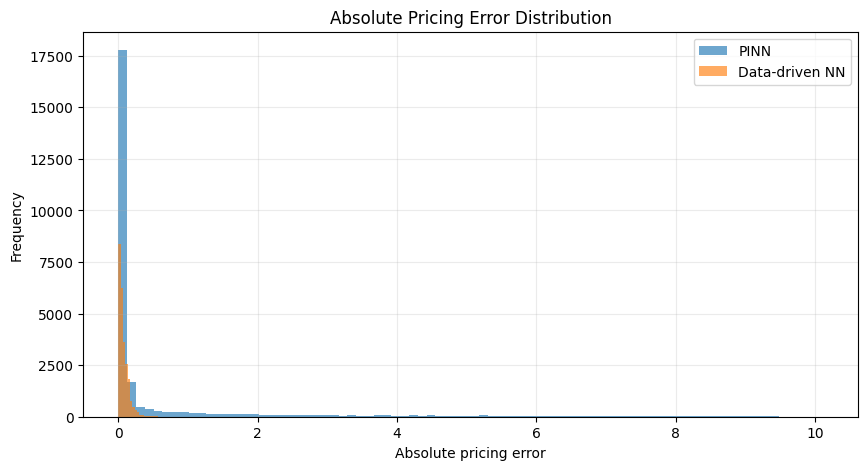

In [60]:
# Error distribution

pinn_abs_err = np.abs(pinn_pred - bs_true)
baseline_abs_err = np.abs(baseline_pred - bs_true)

plt.figure(figsize=(10, 5))
plt.hist(pinn_abs_err, bins=80, alpha=0.65, label="PINN")
plt.hist(baseline_abs_err, bins=80, alpha=0.65, label="Data-driven NN")
plt.xlabel("Absolute pricing error")
plt.ylabel("Frequency")
plt.title("Absolute Pricing Error Distribution")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

,Moneyness,PINN MAE,Baseline MAE,Count
0,0.0-0.2,0.091386,0.055426,2490
1,0.2-0.4,0.085674,0.073761,2486
2,0.4-0.6,0.115869,0.093847,2549
3,0.6-0.8,0.178845,0.083523,2524
4,0.8-1.0,2.869514,0.190087,2473
5,1.0-1.2,2.743830,0.125205,2490
6,1.2-1.4,0.267625,0.040368,2537
7,1.4-1.6,0.041114,0.037640,2503
8,1.6-1.8,0.026384,0.033584,2467
9,1.8-2.0,0.040955,0.080687,2481


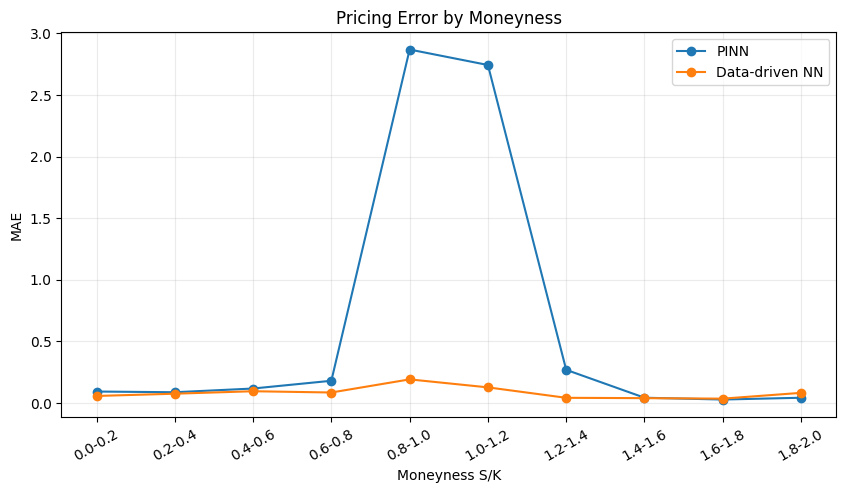

In [61]:
# Error by moneyness

moneyness = S_eval / float(K)
bins = np.linspace(0.0, 2.0, 11)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

rows = []
for i in range(len(bins)-1):
    mask = (moneyness >= bins[i]) & (moneyness < bins[i+1])
    if np.any(mask):
        rows.append({
            "Moneyness": labels[i],
            "PINN MAE": np.mean(np.abs(pinn_pred[mask] - bs_true[mask])),
            "Baseline MAE": np.mean(np.abs(baseline_pred[mask] - bs_true[mask])),
            "Count": int(mask.sum())
        })

moneyness_df = pd.DataFrame(rows)
display(moneyness_df)

plt.figure(figsize=(10, 5))
plt.plot(moneyness_df["Moneyness"], moneyness_df["PINN MAE"], marker="o", label="PINN")
plt.plot(moneyness_df["Moneyness"], moneyness_df["Baseline MAE"], marker="o", label="Data-driven NN")
plt.xlabel("Moneyness S/K")
plt.ylabel("MAE")
plt.title("Pricing Error by Moneyness")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

,Elapsed-time interval,PINN MAE,Baseline MAE,Count
0,0.00-0.12,1.115068,0.093272,3065
1,0.12-0.25,1.046621,0.048998,3219
2,0.25-0.38,0.870446,0.051320,3130
3,0.38-0.50,0.709794,0.072272,3102
4,0.50-0.62,0.538654,0.084474,3077
5,0.62-0.75,0.440513,0.072548,3072
6,0.75-0.88,0.280603,0.059514,3197
7,0.88-1.00,0.141330,0.169354,3138


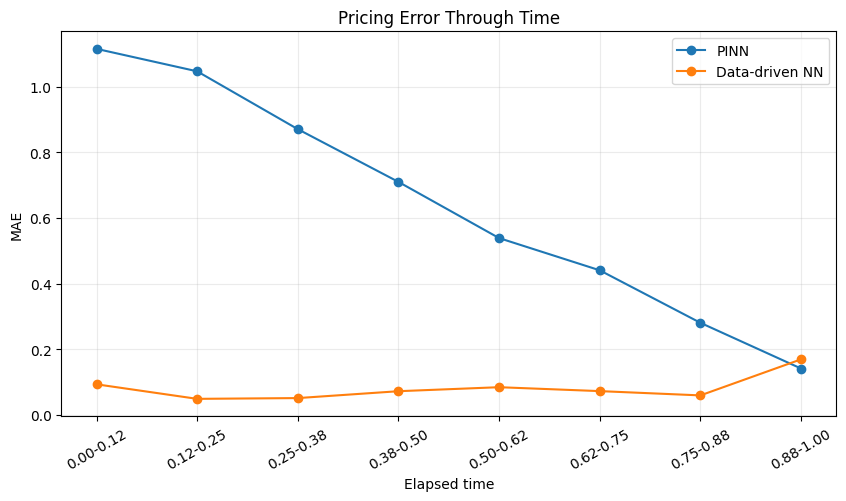

In [62]:
# Error by elapsed time

time_bins = np.linspace(0.0, float(T), 9)
time_rows = []

for i in range(len(time_bins)-1):
    mask = (t_eval >= time_bins[i]) & (t_eval < time_bins[i+1])
    if np.any(mask):
        time_rows.append({
            "Elapsed-time interval": f"{time_bins[i]:.2f}-{time_bins[i+1]:.2f}",
            "PINN MAE": np.mean(np.abs(pinn_pred[mask] - bs_true[mask])),
            "Baseline MAE": np.mean(np.abs(baseline_pred[mask] - bs_true[mask])),
            "Count": int(mask.sum())
        })

time_df = pd.DataFrame(time_rows)
display(time_df)

plt.figure(figsize=(10, 5))
plt.plot(time_df["Elapsed-time interval"], time_df["PINN MAE"], marker="o", label="PINN")
plt.plot(time_df["Elapsed-time interval"], time_df["Baseline MAE"], marker="o", label="Data-driven NN")
plt.xlabel("Elapsed time")
plt.ylabel("MAE")
plt.title("Pricing Error Through Time")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

,min,max,mean
S,,,
0.0,0.080702,0.129921,0.111190
280.0,139.943100,146.643539,143.334412


Terminal-condition metrics:
MSE: 0.004862823523581028
RMSE: 0.06973394751548767
MAE: 0.06608642637729645
Median AE: 0.06889724731445312
Max AE: 0.1300927847623825
R2: 0.999997615814209
Mean Relative Error (%): 0.14820341765880585
Median Relative Error (%): 0.07955111563205719
Relative-error sample size: 248


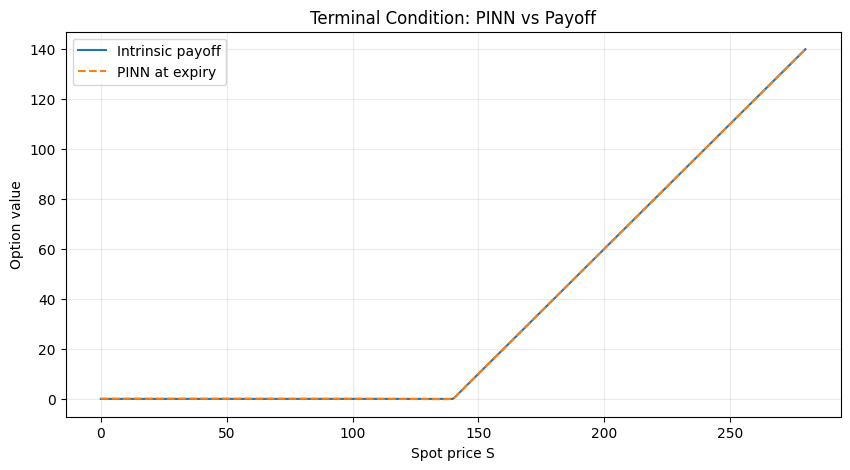

In [63]:
# Boundary and terminal diagnostics

S_min, S_max = 0.0, float(K) * 2.0

S_boundary = np.array([S_min, S_max], dtype=np.float32)
t_boundary = np.linspace(0.0, float(T), 200, dtype=np.float32)

grid = []
for s in S_boundary:
    for tt in t_boundary:
        grid.append([tt, s])

grid = torch.tensor(grid, dtype=torch.float32, device=device)

with torch.no_grad():
    boundary_pred = pinn(grid).detach().cpu().numpy().reshape(-1)

boundary_df = pd.DataFrame({
    "t": np.tile(t_boundary, 2),
    "S": np.repeat(S_boundary, len(t_boundary)),
    "PINN price": boundary_pred
})

display(boundary_df.groupby("S")["PINN price"].agg(["min", "max", "mean"]))

S_term = np.linspace(0.0, S_max, 500, dtype=np.float32)
t_term = np.full_like(S_term, float(T))

with torch.no_grad():
    terminal_x = torch.tensor(
        np.column_stack([t_term, S_term]),
        dtype=torch.float32,
        device=device
    )
    terminal_pred = pinn(terminal_x).detach().cpu().numpy().reshape(-1)

terminal_true = np.maximum(S_term - float(K), 0.0)
terminal_metrics = robust_metrics(terminal_true, terminal_pred, relative_price_floor=1.0)

print("Terminal-condition metrics:")
for k, v in terminal_metrics.items():
    print(f"{k}: {v}")

plt.figure(figsize=(10, 5))
plt.plot(S_term, terminal_true, label="Intrinsic payoff")
plt.plot(S_term, terminal_pred, "--", label="PINN at expiry")
plt.xlabel("Spot price S")
plt.ylabel("Option value")
plt.title("Terminal Condition: PINN vs Payoff")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Mean |PDE residual| : 0.131433
RMS PDE residual    : 0.291930
Max |PDE residual|  : 3.612002


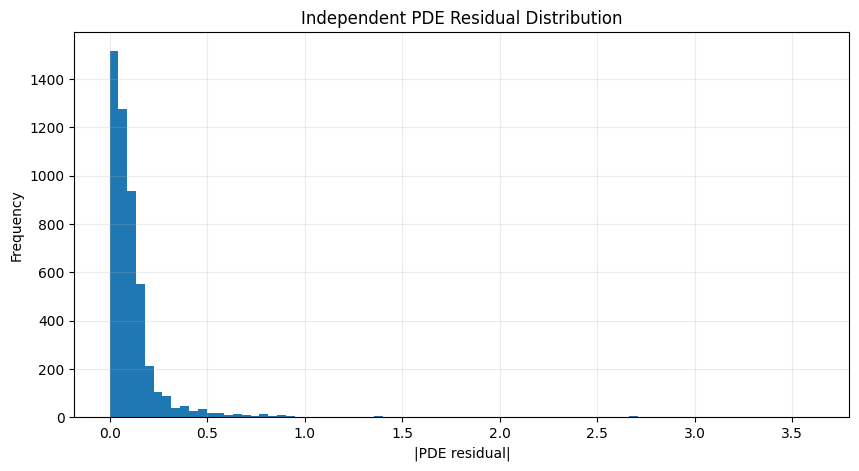

In [64]:
# Independent PDE validation

def compute_pde_residual_elapsed(model, S, t, K_value, r_value, sigma_value):
    S = S.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    x = torch.cat([t, S], dim=1)
    C = model(x)

    dC_dt = torch.autograd.grad(
        C, t, grad_outputs=torch.ones_like(C),
        create_graph=True, retain_graph=True
    )[0]

    dC_dS = torch.autograd.grad(
        C, S, grad_outputs=torch.ones_like(C),
        create_graph=True, retain_graph=True
    )[0]

    d2C_dS2 = torch.autograd.grad(
        dC_dS, S, grad_outputs=torch.ones_like(dC_dS),
        create_graph=False, retain_graph=False
    )[0]

    return (
        dC_dt
        + 0.5 * (sigma_value * S)**2 * d2C_dS2
        + r_value * S * dC_dS
        - r_value * C
    ).detach().cpu().numpy().reshape(-1)

N_PDE_TEST = 5000
S_pde = torch.tensor(
    rng.uniform(1e-4, float(K) * 2.0, N_PDE_TEST),
    dtype=torch.float32, device=device
).reshape(-1, 1)
t_pde = torch.tensor(
    rng.uniform(0.0, float(T) - 1e-6, N_PDE_TEST),
    dtype=torch.float32, device=device
).reshape(-1, 1)

res = compute_pde_residual_elapsed(
    pinn, S_pde, t_pde,
    float(K), float(r), float(sigma)
)

print(f"Mean |PDE residual| : {np.mean(np.abs(res)):.6f}")
print(f"RMS PDE residual    : {np.sqrt(np.mean(res**2)):.6f}")
print(f"Max |PDE residual|  : {np.max(np.abs(res)):.6f}")

plt.figure(figsize=(10, 5))
plt.hist(np.abs(res), bins=80)
plt.xlabel("|PDE residual|")
plt.ylabel("Frequency")
plt.title("Independent PDE Residual Distribution")
plt.grid(alpha=0.25)
plt.show()

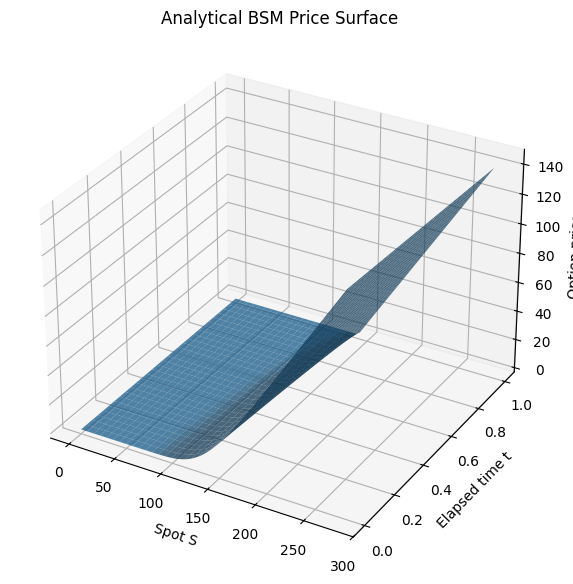

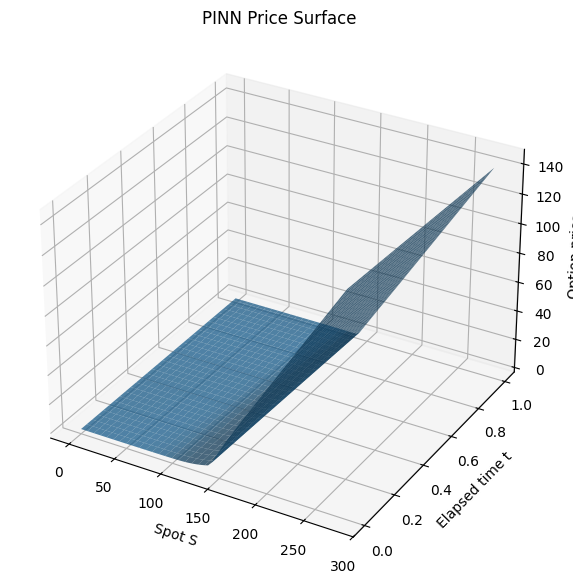

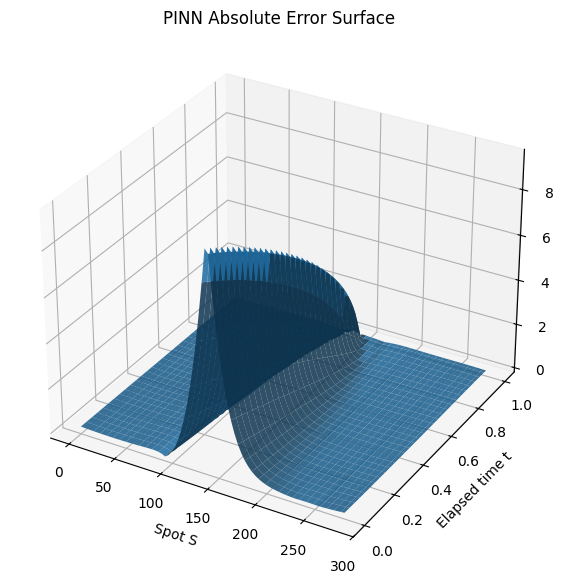

In [65]:
# Surface comparison

from mpl_toolkits.mplot3d import Axes3D

S_grid = np.linspace(0.0, float(K) * 2.0, 80)
t_grid = np.linspace(0.0, float(T), 60)
SS, TT = np.meshgrid(S_grid, t_grid)

flat_x = torch.tensor(
    np.column_stack([TT.ravel(), SS.ravel()]),
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    Z_pinn = pinn(flat_x).detach().cpu().numpy().reshape(TT.shape)

Z_true = BSM_pricing(
    torch.tensor(SS.ravel(), dtype=torch.float32),
    torch.tensor(float(T) - TT.ravel(), dtype=torch.float32),
    torch.tensor(float(K)),
    torch.tensor(float(r)),
    torch.tensor(float(sigma))
).detach().cpu().numpy().reshape(TT.shape)

Z_err = np.abs(Z_pinn - Z_true)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SS, TT, Z_true, alpha=0.75)
ax.set_xlabel("Spot S")
ax.set_ylabel("Elapsed time t")
ax.set_zlabel("Option price")
ax.set_title("Analytical BSM Price Surface")
plt.show()

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SS, TT, Z_pinn, alpha=0.75)
ax.set_xlabel("Spot S")
ax.set_ylabel("Elapsed time t")
ax.set_zlabel("Option price")
ax.set_title("PINN Price Surface")
plt.show()

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SS, TT, Z_err, alpha=0.85)
ax.set_xlabel("Spot S")
ax.set_ylabel("Elapsed time t")
ax.set_zlabel("Absolute error")
ax.set_title("PINN Absolute Error Surface")
plt.show()

In [66]:
# Parameter stress test

stress_cases = [
    {"r": float(r), "sigma": float(sigma), "label": "In-domain parameters"},
    {"r": float(r) + 0.01, "sigma": float(sigma), "label": "Higher rate"},
    {"r": float(r), "sigma": float(sigma) + 0.05, "label": "Higher volatility"},
]

stress_rows = []

for case in stress_cases:
    true_case = BSM_pricing(
        torch.tensor(S_eval, dtype=torch.float32),
        torch.tensor(tau_eval, dtype=torch.float32),
        torch.tensor(float(K), dtype=torch.float32),
        torch.tensor(case["r"], dtype=torch.float32),
        torch.tensor(case["sigma"], dtype=torch.float32)
    ).detach().cpu().numpy().reshape(-1)

    m = robust_metrics(true_case, pinn_pred)

    stress_rows.append({
        "Case": case["label"],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "R2": m["R2"]
    })

stress_df = pd.DataFrame(stress_rows)
display(stress_df)

,Case,RMSE,MAE,R2
0,In-domain parameters,1.663612,0.642572,0.998700
1,Higher rate,1.909365,0.982701,0.998308
2,Higher volatility,2.350104,0.997007,0.997389


In [67]:
# Market calibration summary

if "live_metrics" in globals():
    print("Live-market calibration metrics")
    for k, v in live_metrics.items():
        print(f"{k}: {v}")
else:
    print("Run the original live calibration section first.")

Live-market calibration metrics
MSE: 1.3808237713583493
RMSE: 1.1750845805125474
MAE: 1.0842671379064903
Max Absolute Error: 3.000946044921875
Mean Relative Error (%): 10842671379.064903
Median Relative Error (%): 10507812500.0
R2: -10770425415.595125


In [68]:
# Market PDE diagnostic

# This diagnostic assumes the live model's first input is time-to-maturity tau.
# It therefore uses -dC/dtau in the pricing PDE.

def market_tau_pde_residual(model, X):
    X = X.clone().detach().requires_grad_(True)

    C = model(X)

    tau = X[:, 0:1]
    S = X[:, 1:2]
    K_input = X[:, 2:3]

    dC_dX = torch.autograd.grad(
        C, X, grad_outputs=torch.ones_like(C),
        create_graph=True, retain_graph=True
    )[0]

    C_tau = dC_dX[:, 0:1]
    C_S = dC_dX[:, 1:2]

    d2C_dS2 = torch.autograd.grad(
        C_S, X, grad_outputs=torch.ones_like(C_S),
        create_graph=False, retain_graph=False
    )[0][:, 1:2]

    if hasattr(model, "vol_net"):
        sigma_pred = model.vol_net(X)
    elif hasattr(model, "sigma_net"):
        sigma_pred = model.sigma_net(X)
    else:
        return None

    return (
        -C_tau
        + 0.5 * (sigma_pred * S)**2 * d2C_dS2
        + float(r) * S * C_S
        - float(r) * C
    ).detach().cpu().numpy().reshape(-1)

print("Market tau-PDE diagnostic helper defined.")

Market tau-PDE diagnostic helper defined.


Delta MAE : 0.05465148853214375
Gamma MAE : 0.0035971478


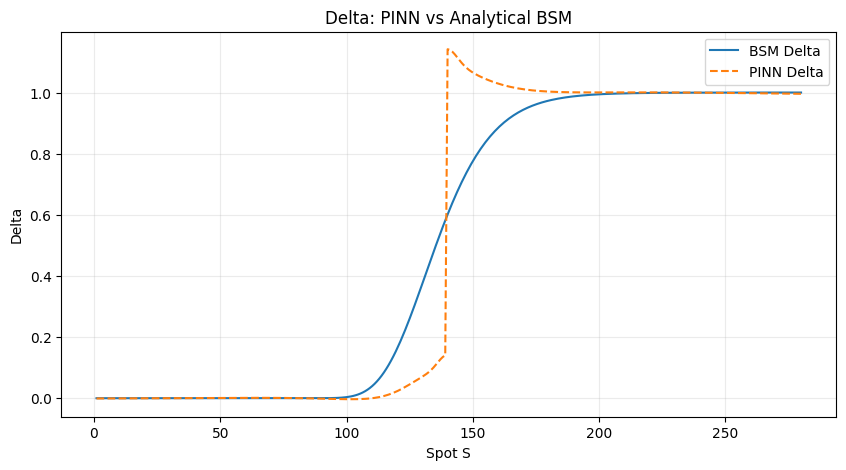

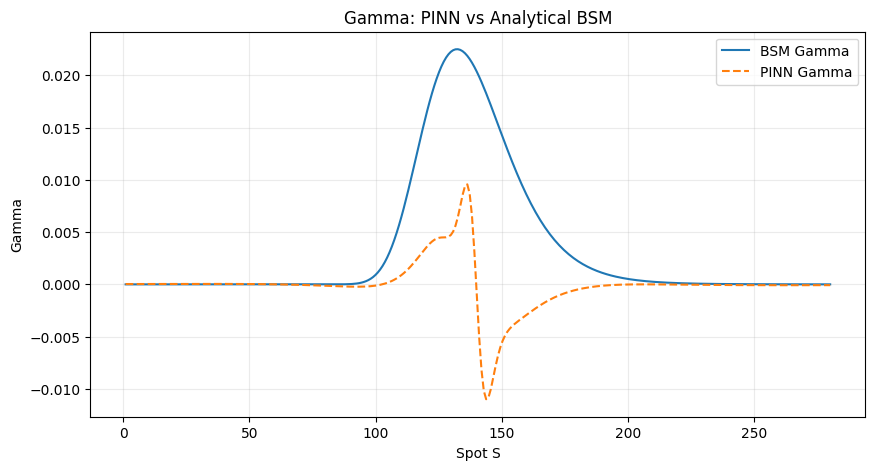

In [69]:
# Greek diagnostics

def bsm_delta(S, tau, K_value, r_value, sigma_value):
    S = np.asarray(S)
    tau = np.maximum(np.asarray(tau), 1e-8)

    d1 = (
        np.log(np.maximum(S, 1e-12) / K_value)
        + (r_value + 0.5 * sigma_value**2) * tau
    ) / (sigma_value * np.sqrt(tau))

    from math import erf, sqrt
    N = 0.5 * (1.0 + np.vectorize(erf)(d1 / np.sqrt(2.0)))
    return N

def bsm_gamma(S, tau, K_value, r_value, sigma_value):
    S = np.maximum(np.asarray(S), 1e-12)
    tau = np.maximum(np.asarray(tau), 1e-8)

    d1 = (
        np.log(S / K_value)
        + (r_value + 0.5 * sigma_value**2) * tau
    ) / (sigma_value * np.sqrt(tau))

    return np.exp(-0.5 * d1**2) / (
        S * sigma_value * np.sqrt(2*np.pi*tau)
    )

S_g = np.linspace(1.0, float(K)*2.0, 300, dtype=np.float32)
tau_g = np.linspace(0.03, float(T), 300, dtype=np.float32)

Xg = torch.tensor(
    np.column_stack([float(T) - tau_g, S_g]),
    dtype=torch.float32,
    device=device
).requires_grad_(True)

C = pinn(Xg)

dC = torch.autograd.grad(
    C, Xg, grad_outputs=torch.ones_like(C),
    create_graph=True
)[0]

delta_pinn = dC[:, 1].detach().cpu().numpy()

gamma_pinn = torch.autograd.grad(
    dC[:, 1:2], Xg,
    grad_outputs=torch.ones_like(dC[:, 1:2]),
    create_graph=False
)[0][:, 1].detach().cpu().numpy()

delta_true = bsm_delta(S_g, tau_g, float(K), float(r), float(sigma))
gamma_true = bsm_gamma(S_g, tau_g, float(K), float(r), float(sigma))

print("Delta MAE :", np.mean(np.abs(delta_pinn - delta_true)))
print("Gamma MAE :", np.mean(np.abs(gamma_pinn - gamma_true)))

plt.figure(figsize=(10, 5))
plt.plot(S_g, delta_true, label="BSM Delta")
plt.plot(S_g, delta_pinn, "--", label="PINN Delta")
plt.xlabel("Spot S")
plt.ylabel("Delta")
plt.title("Delta: PINN vs Analytical BSM")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(S_g, gamma_true, label="BSM Gamma")
plt.plot(S_g, gamma_pinn, "--", label="PINN Gamma")
plt.xlabel("Spot S")
plt.ylabel("Gamma")
plt.title("Gamma: PINN vs Analytical BSM")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [70]:
# Ablation framework

def train_ablation_model(
    model,
    X_data,
    y_data,
    X_pde,
    X_terminal,
    y_terminal,
    epochs=500,
    lr=1e-3,
    use_pde=True,
    use_boundary=True
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred = model(X_data)
        data_loss = torch.mean((pred - y_data)**2)

        loss = data_loss

        if use_boundary:
            term_pred = model(X_terminal)
            terminal_loss = torch.mean((term_pred - y_terminal)**2)
            loss = loss + terminal_loss
        else:
            terminal_loss = torch.tensor(0.0, device=X_data.device)

        if use_pde:
            S = X_pde[:, 1:2].clone().detach().requires_grad_(True)
            t = X_pde[:, 0:1].clone().detach().requires_grad_(True)
            xp = torch.cat([t, S], dim=1)

            Cp = model(xp)

            dCt = torch.autograd.grad(
                Cp, t, torch.ones_like(Cp),
                create_graph=True, retain_graph=True
            )[0]
            dCs = torch.autograd.grad(
                Cp, S, torch.ones_like(Cp),
                create_graph=True, retain_graph=True
            )[0]
            dCss = torch.autograd.grad(
                dCs, S, torch.ones_like(dCs),
                create_graph=True, retain_graph=True
            )[0]

            pde = (
                dCt
                + 0.5 * (float(sigma) * S)**2 * dCss
                + float(r) * S * dCs
                - float(r) * Cp
            )
            pde_loss = torch.mean(pde**2)
            loss = loss + 0.1 * pde_loss
        else:
            pde_loss = torch.tensor(0.0, device=X_data.device)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_history.append([
            float(loss.detach()),
            float(data_loss.detach()),
            float(terminal_loss.detach()),
            float(pde_loss.detach())
        ])

    return np.asarray(loss_history)

print("Ablation trainer ready.")

Ablation trainer ready.


In [71]:
# Ablation

N_ABL = 1500
idx = rng.choice(N_EVAL, size=N_ABL, replace=False)

X_data_ab = torch.tensor(
    np.column_stack([t_eval[idx], S_eval[idx]]),
    dtype=torch.float32,
    device=device
)
y_data_ab = torch.tensor(
    bs_true[idx],
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

N_PDE_ABL = 1000
X_pde_ab = torch.tensor(
    np.column_stack([
        rng.uniform(0.0, float(T), N_PDE_ABL),
        rng.uniform(1e-4, float(K)*2.0, N_PDE_ABL)
    ]),
    dtype=torch.float32,
    device=device
)

S_term_ab = rng.uniform(0.0, float(K)*2.0, 500)
X_term_ab = torch.tensor(
    np.column_stack([np.full(500, float(T)), S_term_ab]),
    dtype=torch.float32,
    device=device
)
y_term_ab = torch.tensor(
    np.maximum(S_term_ab - float(K), 0.0),
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

def make_small_pinn():

    return StablePINN().to(device)

ablation_results = []
ablation_histories = {}

for name, use_pde, use_boundary in [
    ("Data + Physics + Boundary", True, True),
    ("Data + Boundary", False, True),
    ("Data Only", False, False),
]:
    model = make_small_pinn()

    hist = train_ablation_model(
        model,
        X_data_ab,
        y_data_ab,
        X_pde_ab,
        X_term_ab,
        y_term_ab,
        epochs=300,
        lr=1e-3,
        use_pde=use_pde,
        use_boundary=use_boundary
    )

    with torch.no_grad():
        pred = model(
            torch.tensor(
                np.column_stack([t_eval, S_eval]),
                dtype=torch.float32,
                device=device
            )
        ).detach().cpu().numpy().reshape(-1)

    m = robust_metrics(bs_true, pred)

    S_chk = torch.tensor(
        rng.uniform(1e-4, float(K)*2.0, 500),
        dtype=torch.float32,
        device=device
    ).reshape(-1, 1)
    t_chk = torch.tensor(
        rng.uniform(0.0, float(T)-1e-6, 500),
        dtype=torch.float32,
        device=device
    ).reshape(-1, 1)

    if use_pde:
        rchk = compute_pde_residual_elapsed(
            model, S_chk, t_chk, float(K), float(r), float(sigma)
        )
        pde_rmse = float(np.sqrt(np.mean(rchk**2)))
    else:
        pde_rmse = np.nan

    ablation_results.append({
        "Configuration": name,
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "R2": m["R2"],
        "Independent PDE RMSE": pde_rmse
    })
    ablation_histories[name] = hist

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

,Configuration,RMSE,MAE,R2,Independent PDE RMSE
0,Data + Physics + Boundary,0.887918,0.498459,0.999630,2.090353
1,Data + Boundary,0.855621,0.545139,0.999656,NaN
2,Data Only,0.308456,0.224496,0.999955,NaN


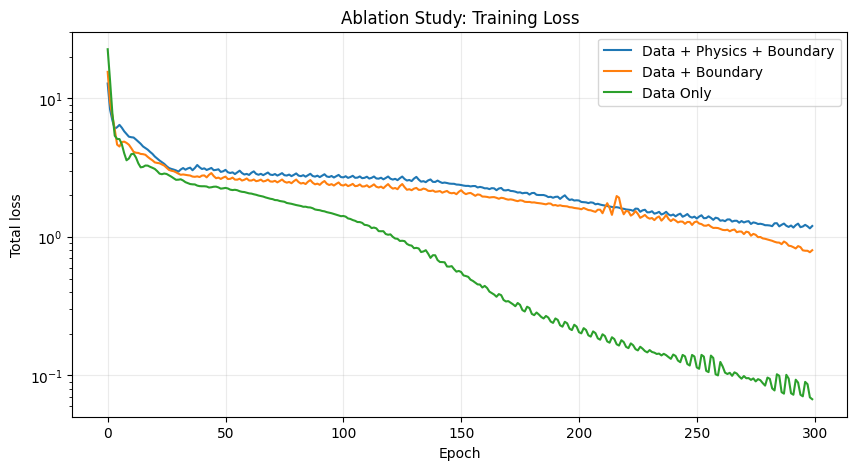

In [72]:
# Ablation curves

plt.figure(figsize=(10, 5))

for name, hist in ablation_histories.items():
    plt.plot(hist[:, 0], label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.title("Ablation Study: Training Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.show()